# Flight Delay Analysis – Project
# Index

1. Project Goal
2. Data Loading
3. Data Overview & Initial Checks
4. Data Cleaning
5. Feature Understanding
6. Exploratory Data Analysis (EDA)
    - Frequency-Based Analysis (Counts)
    - Severity-Based Analysis (Minutes)
7. Correlation Analysis
8. Feature Engineering
9. Feature Analysis
    - Rate Analysis
    - Share Analysis
    - Frequency vs Severity Analysis
10. Time Series Analysis
11. Airline Performance Analysis
12. KPI Section
    - On-Time Performance (OTP)
    - Cancellation Rate
    - ImPax% (Approximation)
    - Disruption Score
13. Airline KPI Summary Table
14. Conclusion and Final Insights

----

## 1. Project Goal

### Objective: 
Analyze airline delay patterns using frequency, severity, and operational efficiency metrics.

Using Jupyter ipython notebook version 6.5.4

## Dataset
### US Flight Delay Data

**Source:** [Kaggle](https://www.kaggle.com/datasets/sriharshaeedala/airline-delay) 
    (derived from the Bureau of Transportation Statistics Airline On-Time Performance dataset)

**Size:** **171,667 rows × 21 columns**
data distributiondata distribution
**Granularity:** Monthly airline performance at the airport level.

----

## 2. Data Loading

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "Airline_Delay_Cause.csv"
df_raw = pd.read_csv(file_path)

----

## 3. Data Overview & Initial Checks

In [2]:
print(f"Number of rows: {df_raw.shape[0]}")
print(f"Number of columns: {df_raw.shape[1]}")

Number of rows: 171666
Number of columns: 21


----

In [3]:
print("--- Dataset Info ---")
print(df_raw.info())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  object 
 3   carrier_name         171666 non-null  object 
 4   airport              171666 non-null  object 
 5   airport_name         171666 non-null  object 
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 

----

In [4]:
print("\n--- First 5 Rows ---")
print(df_raw.head())


--- First 5 Rows ---
   year  month carrier       carrier_name airport  \
0  2023      8      9E  Endeavor Air Inc.     ABE   
1  2023      8      9E  Endeavor Air Inc.     ABY   
2  2023      8      9E  Endeavor Air Inc.     AEX   
3  2023      8      9E  Endeavor Air Inc.     AGS   
4  2023      8      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         89.0       13.0   
1             Albany, GA: Southwest Georgia Regional         62.0       10.0   
2           Alexandria, LA: Alexandria International         62.0       10.0   
3        Augusta, GA: Augusta Regional at Bush Field         66.0       12.0   
4                   Albany, NY: Albany International         92.0       22.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        2.25        1.60  ...          0.0              5.99            2.0   
1        1.97     

----

### Column Explanations

### Time Information

- **Year** – Year in which the flights were recorded.
- **Month** – Month of the recorded flights (1–12).

### Airline Information

- **Carrier** – Unique airline code identifier.
- **Carrier Name** – Full name of the airline.

### Airport Information

- **Airport** – Airport IATA code where the flight arrived.
- **Airport Name** – Full name and location of the airport.

### Flight Volume Metrics

- **Arr Flights** – Total number of arriving flights for the airline at the airport during the month.
- **Arr Cancelled** – Number of flights cancelled.
- **Arr Diverted** – Number of flights diverted to another airport.

### Delay Metrics

- **Arr Del15** – Number of flights arriving **15 minutes or more late**.
- **Arr Delay** – Total arrival delay minutes accumulated by all delayed flights.

### Delay Causes (Flight Counts)

- **Carrier Ct** – Number of delayed flights caused by airline operational issues (crew, maintenance, etc.).
- **Weather Ct** – Number of delays caused by weather conditions.
- **NAS Ct** – Delays caused by the **National Aviation System** (air traffic congestion, ATC delays).
- **Security Ct** – Delays caused by security-related issues.
- **Late Aircraft Ct** – Delays caused by aircraft arriving late from previous flights.

### Delay Causes (Minutes)

- **Carrier_Delay** – Total delay minutes caused by airline-related operational issues.
- **Weather_Delay** – Total delay minutes caused by weather conditions.
- **NAS_Delay** – Total delay minutes caused by air traffic system congestion.
- **Security_Delay** – Total delay minutes caused by security issues.
- **Late_Aircraft_Delay** – Total delay minutes caused by late-arriving aircraft.

----

### Statistical Summary

Funtion to create a custom summary for the raw data

In [5]:
def full_stats(df):
    df_stats = df.describe()
    numeric_df = df.select_dtypes(include=['number'])

    median = numeric_df.median(numeric_only=True)
    mode = numeric_df.mode(numeric_only=True).iloc[0]
    range_val = numeric_df.max() - numeric_df.min()
    variance_val = numeric_df.var()
    skewness_val = numeric_df.skew()
    kurtosis_val = numeric_df.kurt()

    extra_stats = pd.DataFrame({
        'median': median,
        'mode': mode,
        'range': range_val,
        'variance': variance_val,
        'skewness': skewness_val,
        'kurtosis': kurtosis_val
    }).T

    df_stats_raw_full = pd.concat([df_stats, extra_stats])
    return df_stats_raw_full

In [6]:
print("--- Full Statistical Summary ---")
print(full_stats(df_raw))

--- Full Statistical Summary ---
                   year          month    arr_flights      arr_del15  \
count     171666.000000  171666.000000  171426.000000  171223.000000   
mean        2018.551361       6.493633     362.528467      66.434387   
std            2.890006       3.440908     992.894662     179.540694   
min         2013.000000       1.000000       1.000000       0.000000   
25%         2016.000000       4.000000      50.000000       6.000000   
50%         2019.000000       7.000000     100.000000      17.000000   
75%         2021.000000       9.000000     250.000000      47.000000   
max         2023.000000      12.000000   21977.000000    4176.000000   
median      2019.000000       7.000000     100.000000      17.000000   
mode        2019.000000       8.000000      31.000000       0.000000   
range         10.000000      11.000000   21976.000000    4176.000000   
variance       8.352137      11.839848  985839.810270   32234.860781   
skewness      -0.254111      -0

----

## 4. Data Cleaning

**3. a. Typecasting categorical features**

Changing 'year' and 'month' to categorical column

In [7]:
df_raw[['year','month']] = df_raw[['year','month']].astype('category')

----

**3. b. Checking for duplicate values**

In [8]:
duplicates = df_raw[df_raw.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [year, month, carrier, carrier_name, airport, airport_name, arr_flights, arr_del15, carrier_ct, weather_ct, nas_ct, security_ct, late_aircraft_ct, arr_cancelled, arr_diverted, arr_delay, carrier_delay, weather_delay, nas_delay, security_delay, late_aircraft_delay]
Index: []

[0 rows x 21 columns]


In [9]:
del duplicates
# No duplicate rows found so deleting variable

----

**3. c. Checking for missing values**

In [10]:
print("\n--- Missing Values ---")
print(df_raw.isnull().sum())


--- Missing Values ---
year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64


Preliminary data shows highest missing values in arr_del15 feature
Getting value counts of arr_del15 

In [11]:
df_raw['arr_del15'].value_counts(dropna=False).sort_index()

arr_del15
0.0       6585
1.0       6525
2.0       6288
3.0       6106
4.0       6178
          ... 
4024.0       1
4140.0       1
4142.0       1
4176.0       1
NaN        443
Name: count, Length: 1782, dtype: int64

Getting correlation matrix for the missing values accross all features

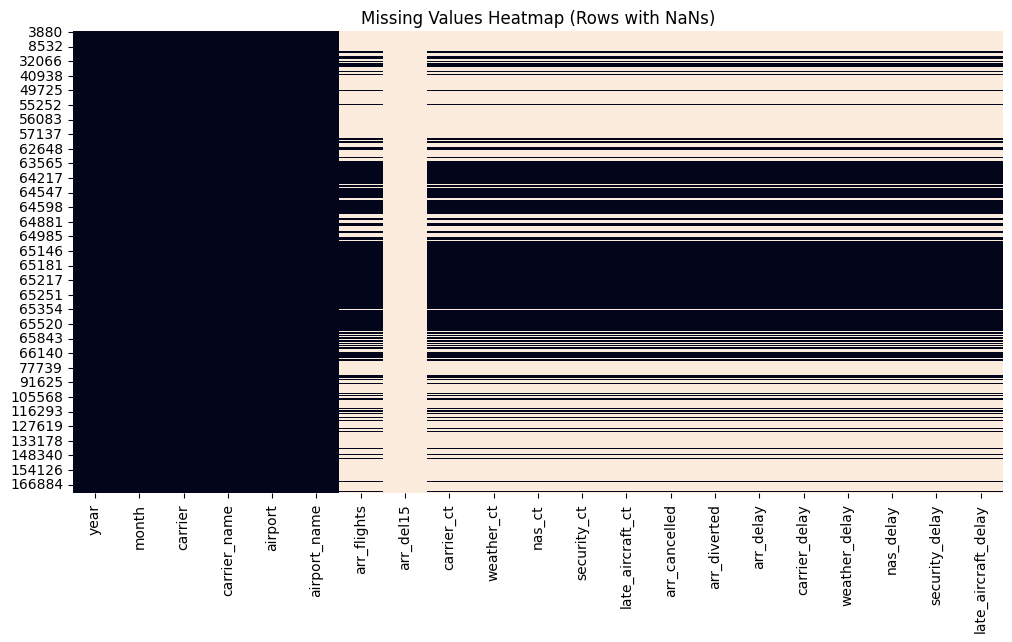

In [12]:
missing_rows = df_raw[df_raw.isna().any(axis=1)]
plt.figure(figsize=(12,6))
sns.heatmap(missing_rows.isna(), cbar=False)
plt.title("Missing Values Heatmap (Rows with NaNs)")
plt.show()

Insight

Missing values appear in structured blocks across delay-related columns, indicating they are not random but event-driven (likely when no delays occurred).
Core identifier fields remain complete, which is good for analysis.
Instead of dropping rows, missing delay components will be treated as 0 where logically valid.

In [13]:
del missing_rows

Dropping all rows that have all numeric values missing

In [14]:
numeric_cols = df_raw.select_dtypes(include=['int64','float64']).columns

In [15]:
df_clean = df_raw.dropna(subset=numeric_cols, how='all')

In [16]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171426 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   year                 171426 non-null  category
 1   month                171426 non-null  category
 2   carrier              171426 non-null  object  
 3   carrier_name         171426 non-null  object  
 4   airport              171426 non-null  object  
 5   airport_name         171426 non-null  object  
 6   arr_flights          171426 non-null  float64 
 7   arr_del15            171223 non-null  float64 
 8   carrier_ct           171426 non-null  float64 
 9   weather_ct           171426 non-null  float64 
 10  nas_ct               171426 non-null  float64 
 11  security_ct          171426 non-null  float64 
 12  late_aircraft_ct     171426 non-null  float64 
 13  arr_cancelled        171426 non-null  float64 
 14  arr_diverted         171426 non-null  float64 
 15  arr_d

This verifies the missing values in arr_del15 but valid values in other features

In [17]:
df_clean['arr_del15'].isna().sum()

203

Shows the most frequent value in arr_del15 in order

In [18]:
df_clean['arr_del15'].value_counts(dropna=False).sort_index()

arr_del15
0.0       6585
1.0       6525
2.0       6288
3.0       6106
4.0       6178
          ... 
4024.0       1
4140.0       1
4142.0       1
4176.0       1
NaN        203
Name: count, Length: 1782, dtype: int64

- 240 rows contained missing values across all operational flight statistics, indicating unreported airport-month records. These rows were removed.
- However, 203 rows contained missing values only in arr_del15 while other delay metrics were present, suggesting partial reporting. 
- These rows were retained for further analysis.

**3. d. Handling missing values**

Imputing 0 in the missing values in arr_del15 column - most frequent value.
Also adding 203 values will have negligible impact (0.11%) on the feature.

In [19]:
df_clean.loc[:, 'arr_del15'] = df_clean['arr_del15'].fillna(0)

Verifying missing values in clean dataset

In [20]:
df_clean.isna().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

----

## 5. Feature Understanding

Before proceeding with deeper analysis, it is important to clearly understand **what each type of feature represents**.
In this dataset, multiple columns may look similar (all numeric), but they actually capture **different aspects of airline operations**.
If we do not distinguish them properly:

* Insights may become misleading
* Wrong metrics may be used (e.g., minutes vs counts)
* Business interpretation will be weak

### Core Concept

We classify features into four categories:

### 1. Counts → Frequency

* Represent **how often an event occurs**
* Example: number of delayed flights

arr_del15, carrier_ct, weather_ct, nas_ct, security_ct, late_aircraft_ct

These answer:
> “How frequently does this type of delay happen?”

### 2. Delay (Minutes) → Severity

* Represent **total delay impact**
* Example: total minutes lost due to a cause

arr_delay, carrier_delay, weather_delay, nas_delay, security_delay, late_aircraft_delay

These answer:
> “How severe or costly are these delays?”

### 3. Rates → Efficiency

* Normalize counts or delays by total flights
* Allow **fair comparison across airports/airlines**

delay_rate, cancel_rate, divert_rate

These answer:
> “How efficient is the operation relative to its size?”

### 4. Shares → Composition

* Break total delay into contributing factors
* Show **relative importance of each cause**

carrier_delay_share, weather_delay_share, nas_delay_share,
security_delay_share, late_aircraft_delay_share

These answer:
> “What is causing the delays?”

----

### Practical Verification Using Data

### Compare Frequency vs Severity

In [21]:
# Define delay types
delay_types = ['carrier', 'weather', 'nas', 'security', 'late_aircraft']

data = []

for d in delay_types:
    count = df_clean[f'{d}_ct'].sum()
    minutes = df_clean[f'{d}_delay'].sum()
    
    data.append([
        d.title(),
        round(count),      # Frequency
        round(minutes)     # Severity
    ])

# Create comparison dataframe
comparison_df = pd.DataFrame(data, columns=['Delay_Type', 'Count', 'Minutes'])

comparison_df

,Delay_Type,Count,Minutes
0,Carrier,3565081,246370897
1,Weather,385768,38153170
2,Nas,3322433,157823639
3,Security,26930,1265591
4,Late_Aircraft,4074891,283144335


### Key Insights

By separating features into categories, we can:

* Avoid mixing **frequency with severity**
* Build **correct KPIs (OTP, delay rate, etc.)**
* Perform **meaningful root cause analysis**
* Design better **visualizations and dashboards**

### Summary
Counts  → how often   
Minutes → how bad   
Rates   → efficiency   
Shares  → composition   

----

## 6. Exploratory Data Analysis (EDA)

### 6.1. Frequency based analysis (Counts)

**6.1.1 Data distribution**

Function will generate Distribution & Boxplots for each feature

In [22]:
count_features = ['arr_del15'] + [f'{d}_ct' for d in delay_types]

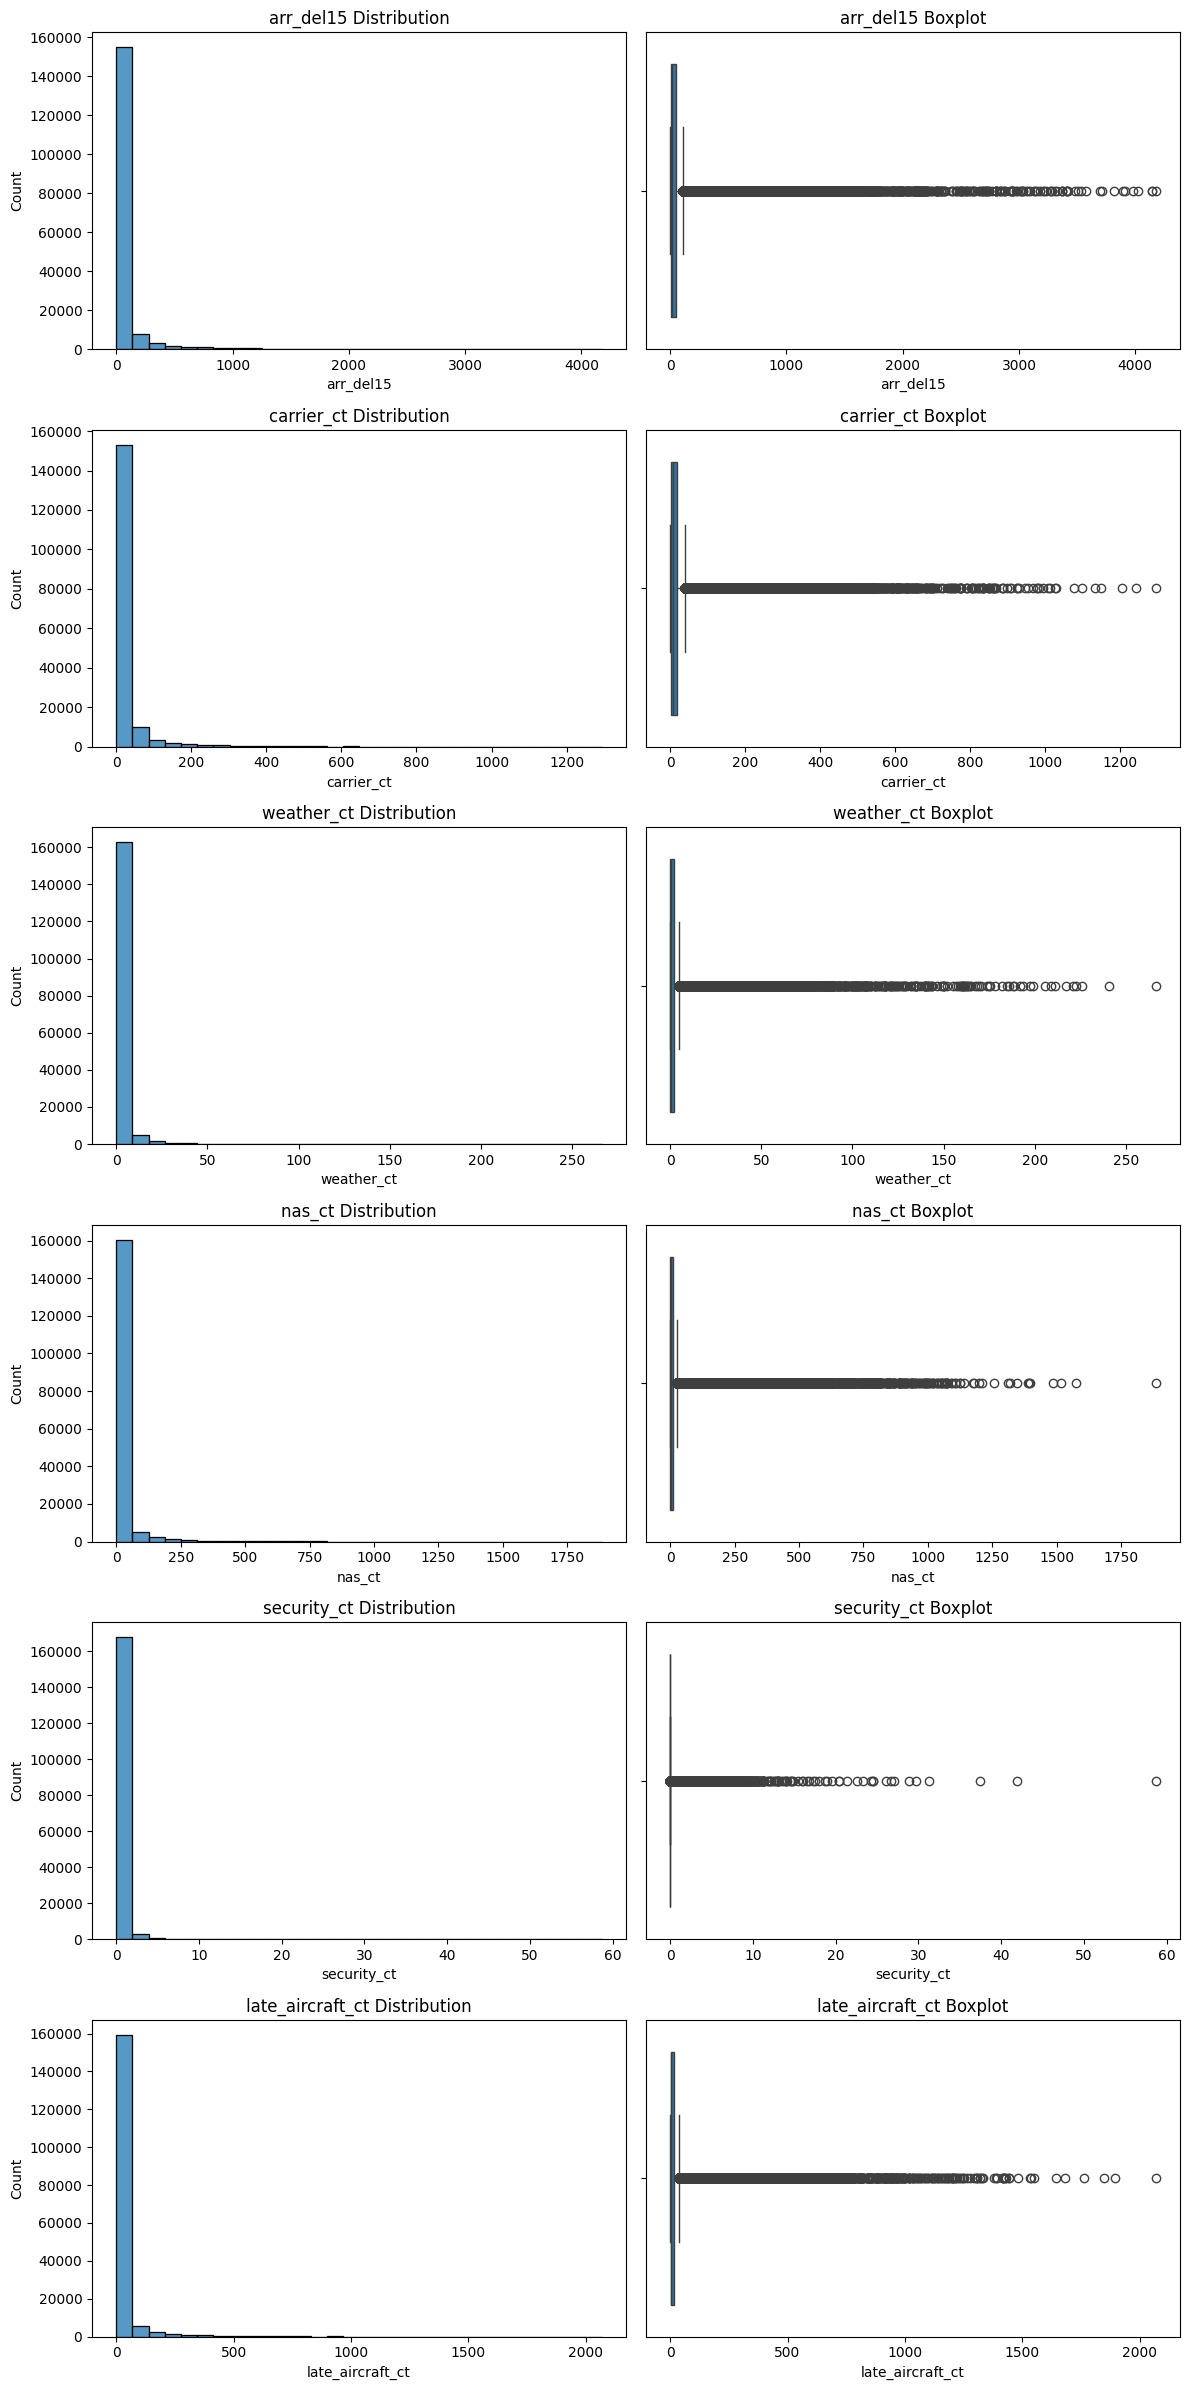

In [23]:
def quick_eda(df, cols):
    n = len(cols)
    rows = n
    cols_layout = 2  # dist + boxplot

    fig, axes = plt.subplots(rows, cols_layout, figsize=(12, 4 * rows))

    # Handle single feature case
    if n == 1:
        axes = [axes]

    for i, col in enumerate(cols):
        sns.histplot(df[col].dropna(), bins=30, ax=axes[i][0])
        axes[i][0].set_title(f'{col} Distribution')

        sns.boxplot(x=df[col].dropna(), ax=axes[i][1])
        axes[i][1].set_title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()

quick_eda(df_clean, count_features)

**Insights**

- The count features in the dataset are extremly right skewed.
- Outliers will not be removed since count features are key operational feature.

----

**6.1.2. Delay Contribution Analysis**

Objective
To understand which delay factors contribute the most to total delay time across all flights.

Methodology
Aggregated total delay minutes for each delay type
Converted them into proportional shares of total delay

In [24]:
data = []

for d in delay_types:
    total_delay = round(df_clean[f'{d}_ct'].sum())
    data.append([d.title(), total_delay])

# Create DataFrame
count_df = pd.DataFrame(data, columns=['Delay_Type', 'Count'])

# Calculate share
count_df['Share'] = count_df['Count'] / count_df['Count'].sum()

count_df

,Delay_Type,Count,Share
0,Carrier,3565081,0.313411
1,Weather,385768,0.033913
2,Nas,3322433,0.292079
3,Security,26930,0.002367
4,Late_Aircraft,4074891,0.358229


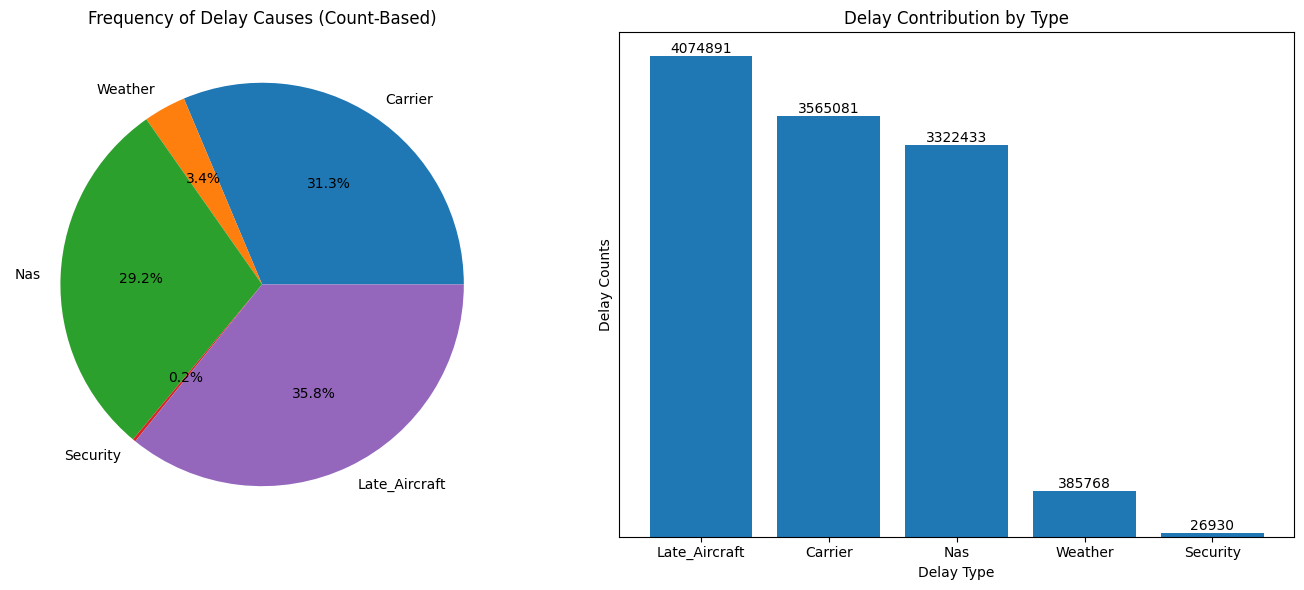

In [25]:
# Sort data for bar chart
count_df_sorted = count_df.sort_values(by='Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(
    count_df['Share'],
    labels=count_df['Delay_Type'],
    autopct='%1.1f%%'
)
axes[0].set_title("Frequency of Delay Causes (Count-Based)")

# Bar chart (sorted)
bars = axes[1].bar(count_df_sorted['Delay_Type'], count_df_sorted['Count'])

# Add data labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

# Remove y-axis ticks but keep label
axes[1].set_yticks([])
axes[1].set_xlabel("Delay Type")
axes[1].set_ylabel("Delay Counts")
axes[1].set_title("Delay Contribution by Type")

plt.tight_layout()

I used a pie chart to show proportional contribution, but for precise comparison I prefer bar charts — so I included both.

**Insights**

This analysis highlights which delay sources dominate system-wide delays
Unlike per-flight analysis, this shows network-level impact

Late Aircraft Delays often contribute the largest share (36%)→ indicates cascading delays
Carrier Delays (31%) reflect internal inefficiencies
NAS delays (29%) shows air traffic control inefficiencies

----

**6.1.3. Time Series of Delay Counts**

This shows how frequently each delay type occurs over time

In [26]:
df_clean = df_clean.copy()

# Merging Month and Year features into a unified Date Feature
df_clean['date'] = pd.to_datetime(
    df_clean['year'].astype(str) + '-' + df_clean['month'].astype(str) + '-01'
)

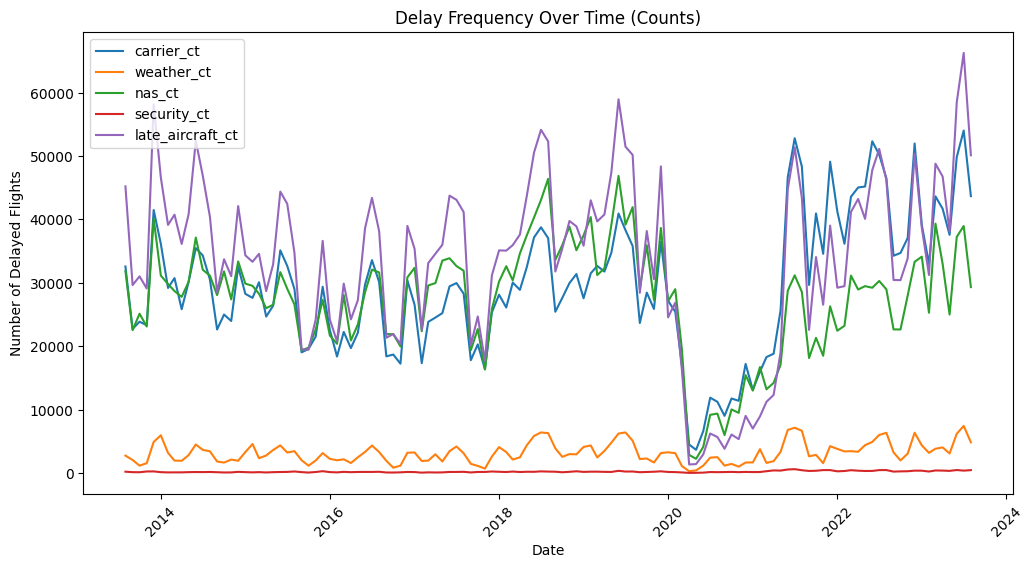

In [27]:
# Group by date and sum counts
# Use delay_types to dynamically select count columns
ct_cols = [f'{d}_ct' for d in delay_types]

ts_counts = df_clean.groupby('date')[ct_cols].sum().reset_index()

# Plot
plt.figure(figsize=(12,6))

for col in ts_counts.columns[1:]:
    plt.plot(ts_counts['date'], ts_counts[col], label=col)

plt.legend()
plt.title("Delay Frequency Over Time (Counts)")
plt.ylabel("Number of Delayed Flights")
plt.xlabel("Date")
plt.xticks(rotation=45)

plt.show()

**Insights from Frequency Analysis**
- Identifies which delay types occur most often
- Highlights operational inefficiencies (high frequency)
- Useful for resource allocation and process improvement

----

### 6.2 Severity-Based Analysis (Minutes)

**6.2.1 Data distribution**

In [28]:
minutes_delay_features = ['arr_delay'] + [f'{d}_delay' for d in delay_types]

Generating Distribution & Boxplots for each feature

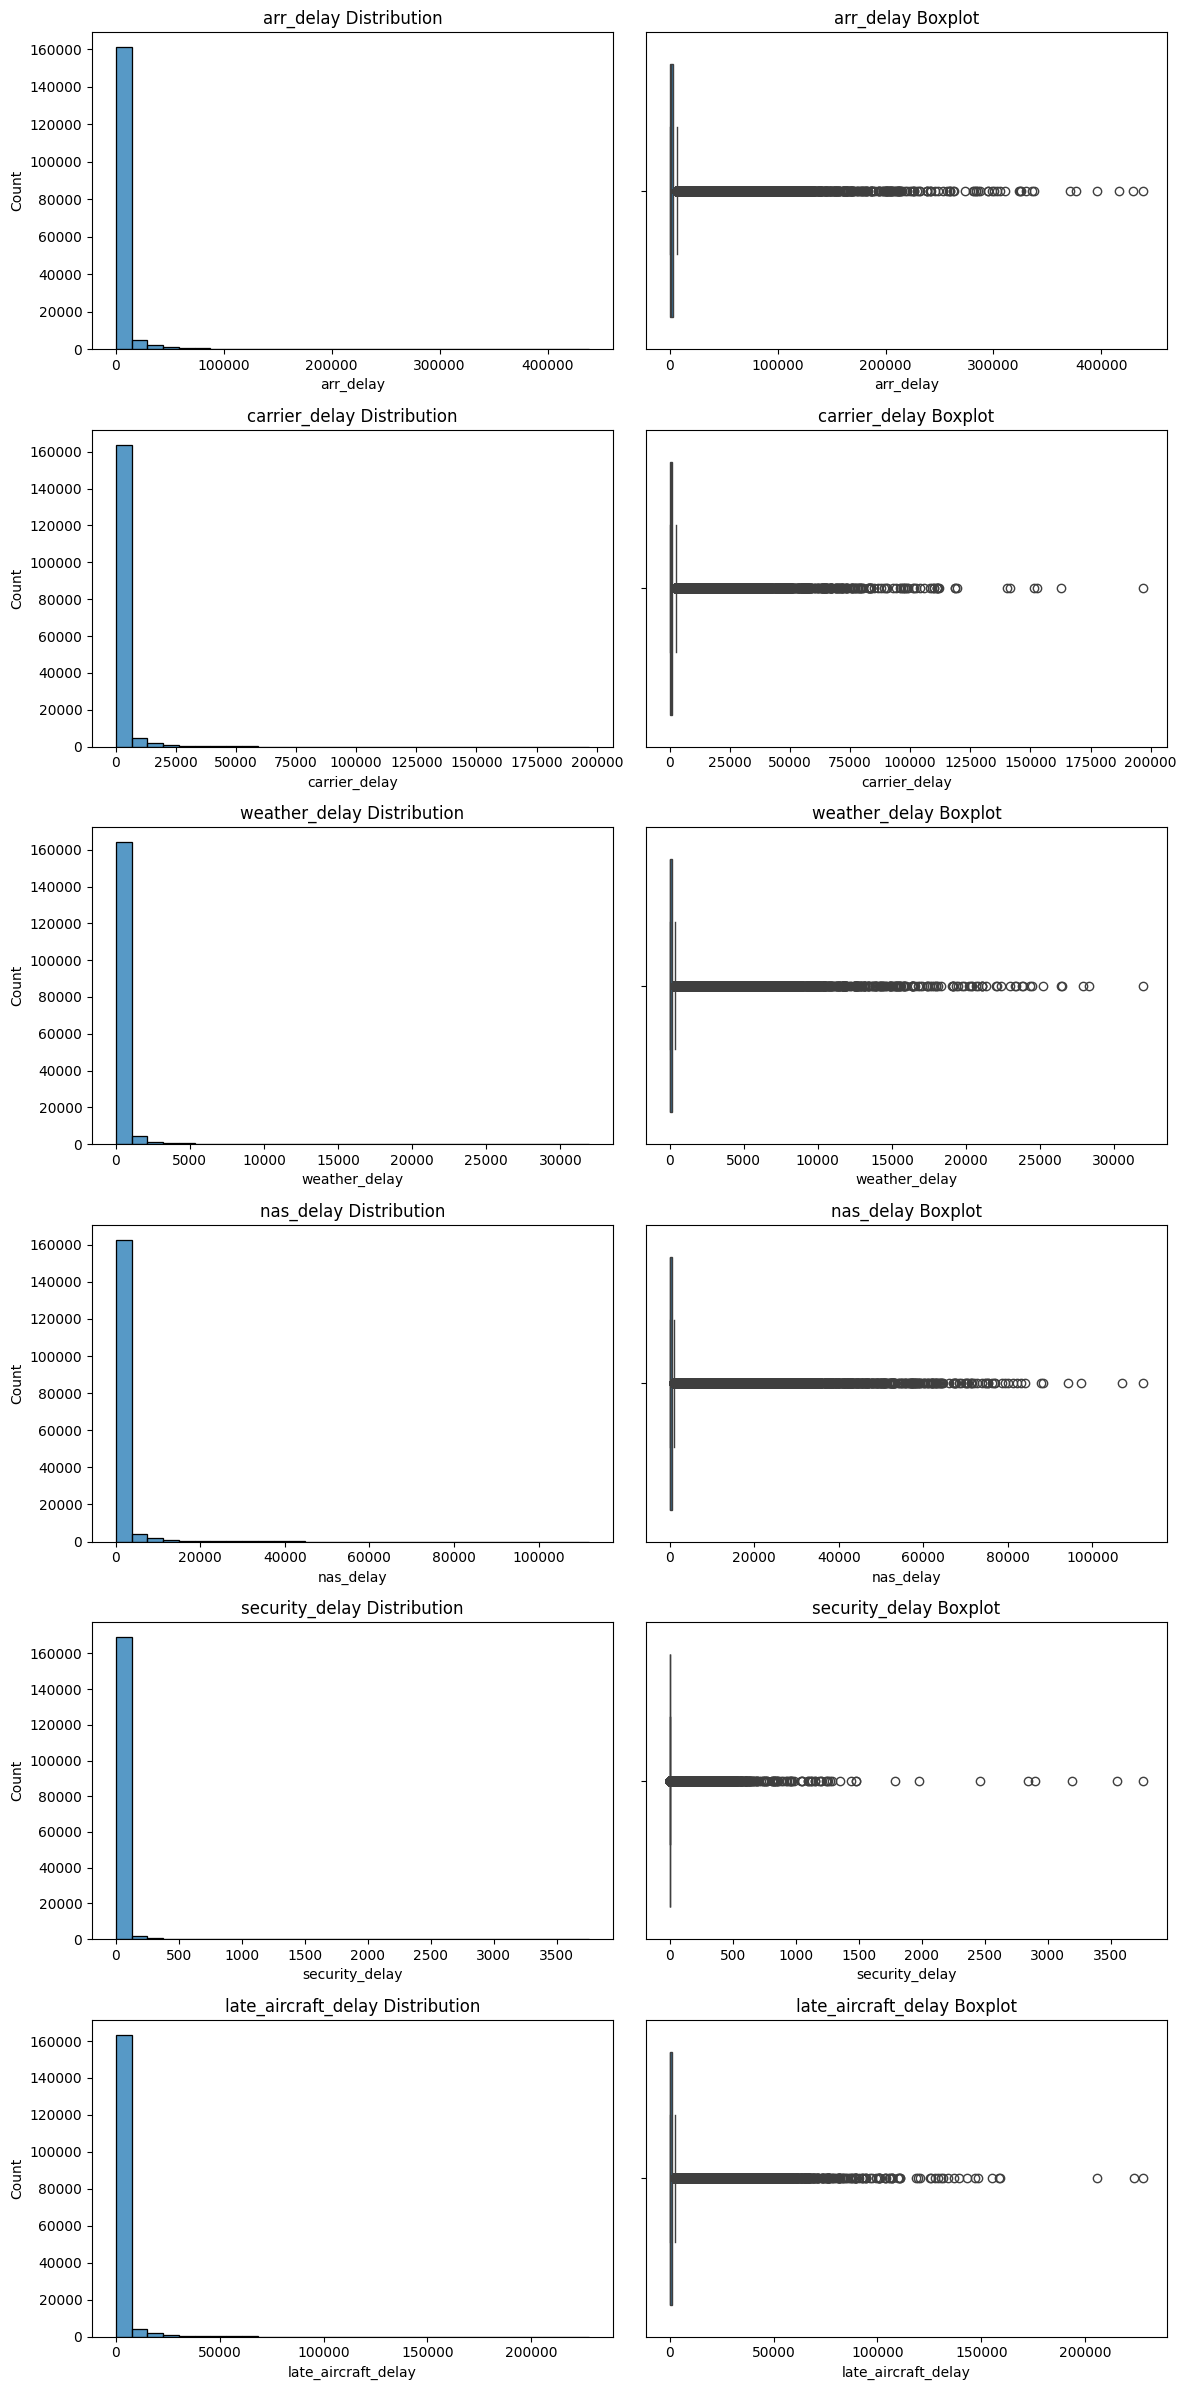

In [29]:
quick_eda(df_clean, minutes_delay_features)

**Insights**

- Delay features are extremely right skewed
- Extreme upper outliers will be capped to remove spikes.

----

**6.2.2 Outlier Capping**

In [30]:
df_winsorized = df_clean.copy()

for col in minutes_delay_features:
    upper = df_winsorized[col].quantile(0.99)
    df_winsorized[col] = df_winsorized[col].clip(upper=upper)

Generating Distribution & Boxplots for each feature after winsorization

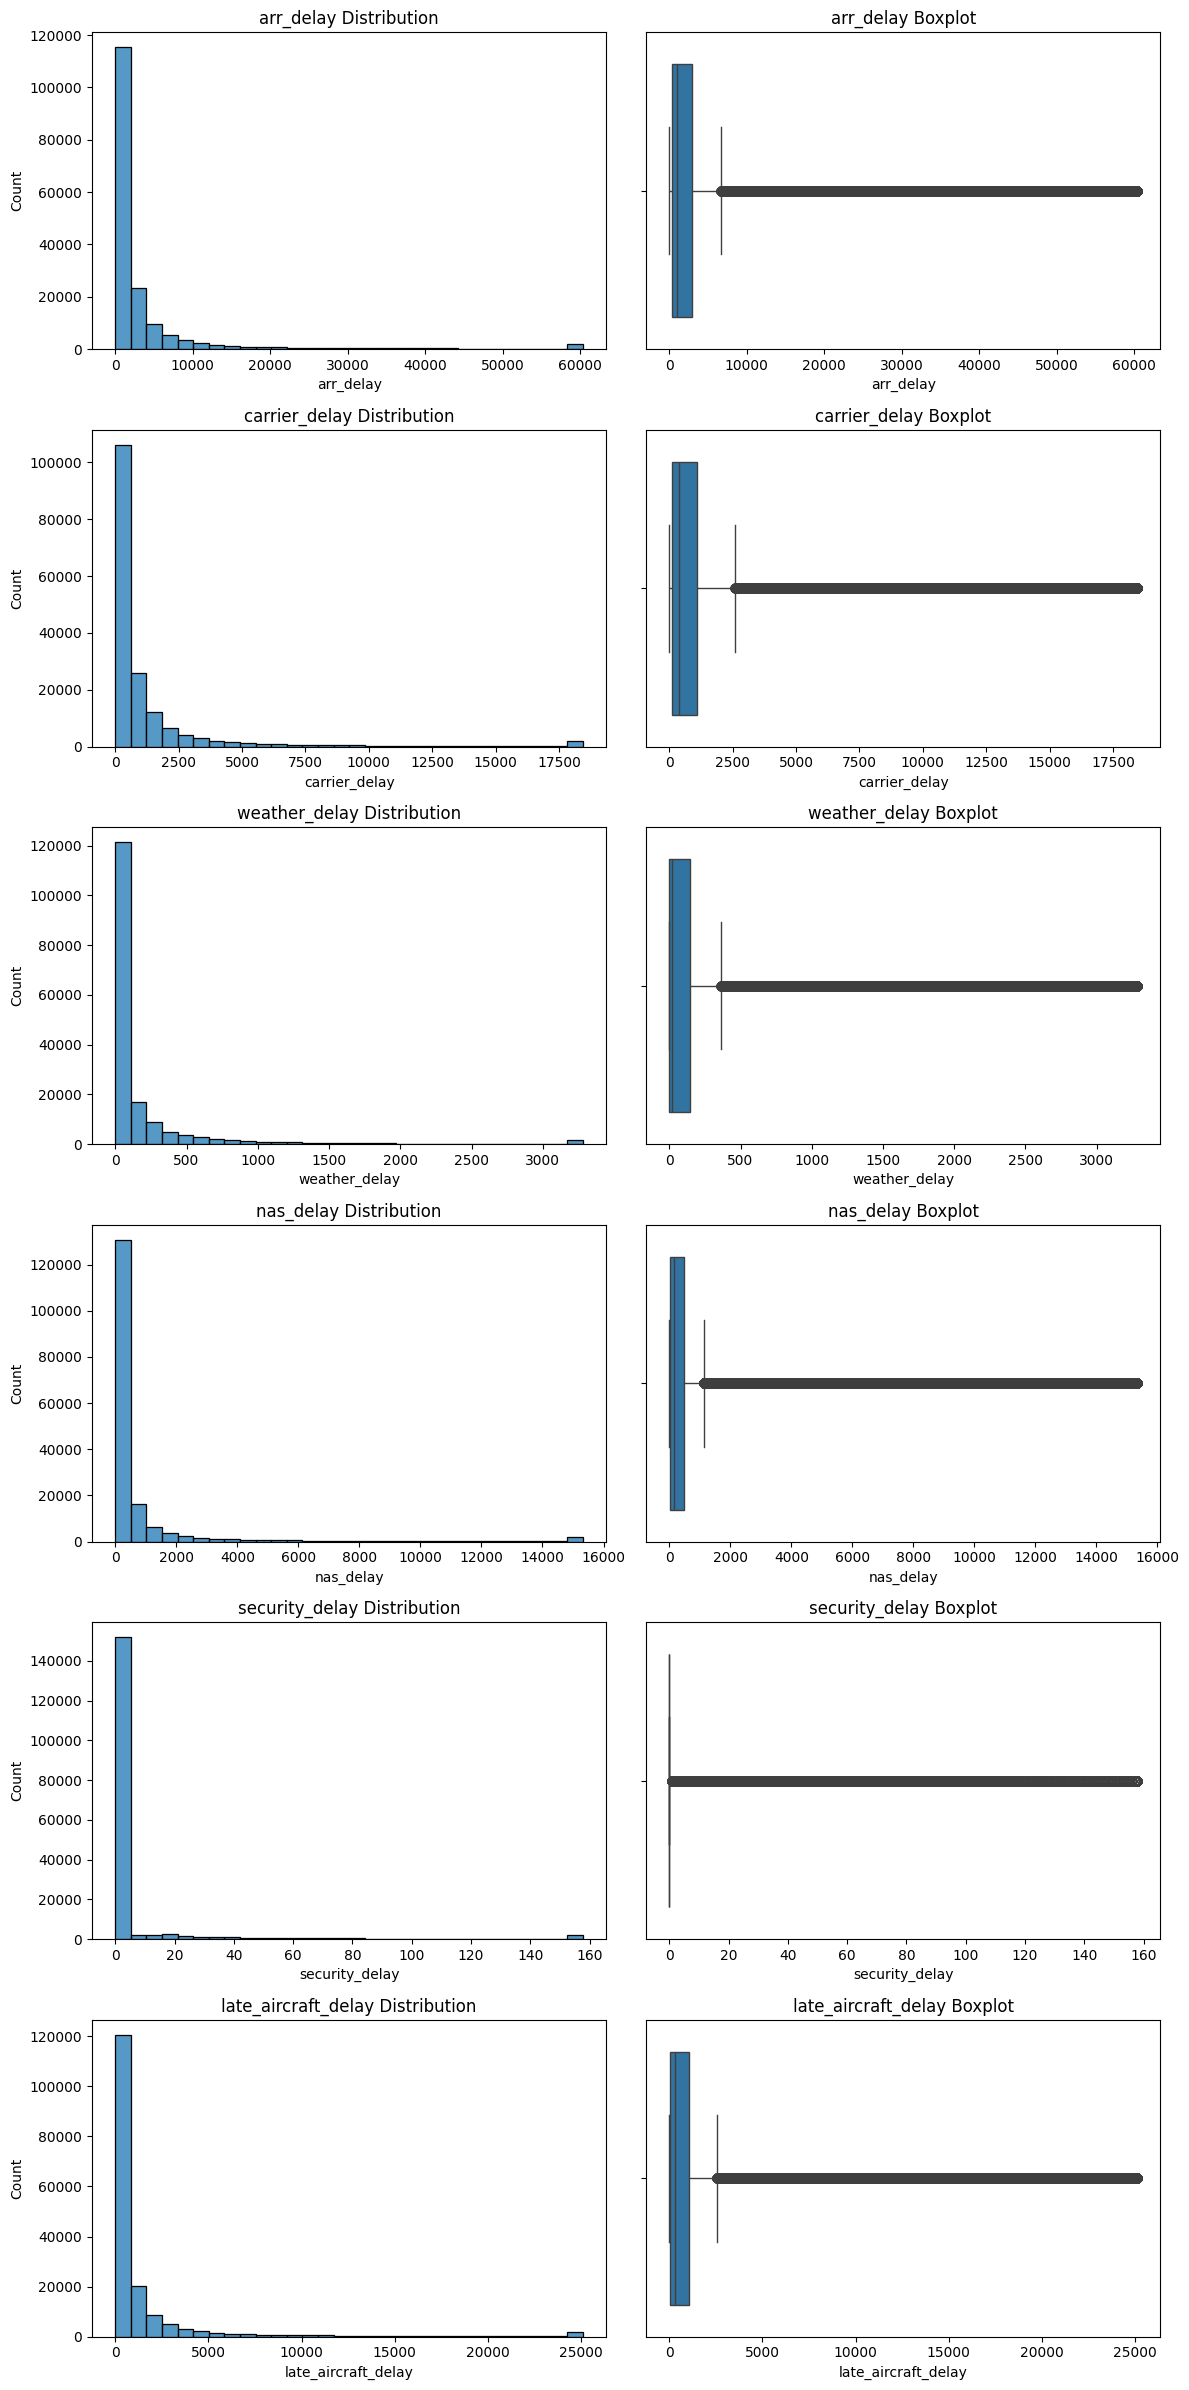

In [31]:
quick_eda(df_winsorized, minutes_delay_features)

----

**6.2.3 Delay minutes analysis**

In [32]:
data = []

for d in delay_types:
    total_delay = round(df_clean[f'{d}_delay'].sum())
    data.append([d.title(), total_delay])

# Create DataFrame
delay_df = pd.DataFrame(data, columns=['Delay_Type', 'Total_Delay'])

# Calculate overall share
delay_df['Share'] = delay_df['Total_Delay'] / delay_df['Total_Delay'].sum()

delay_df

,Delay_Type,Total_Delay,Share
0,Carrier,246370897,0.339000
1,Weather,38153170,0.052498
2,Nas,157823639,0.217161
3,Security,1265591,0.001741
4,Late_Aircraft,283144335,0.389599


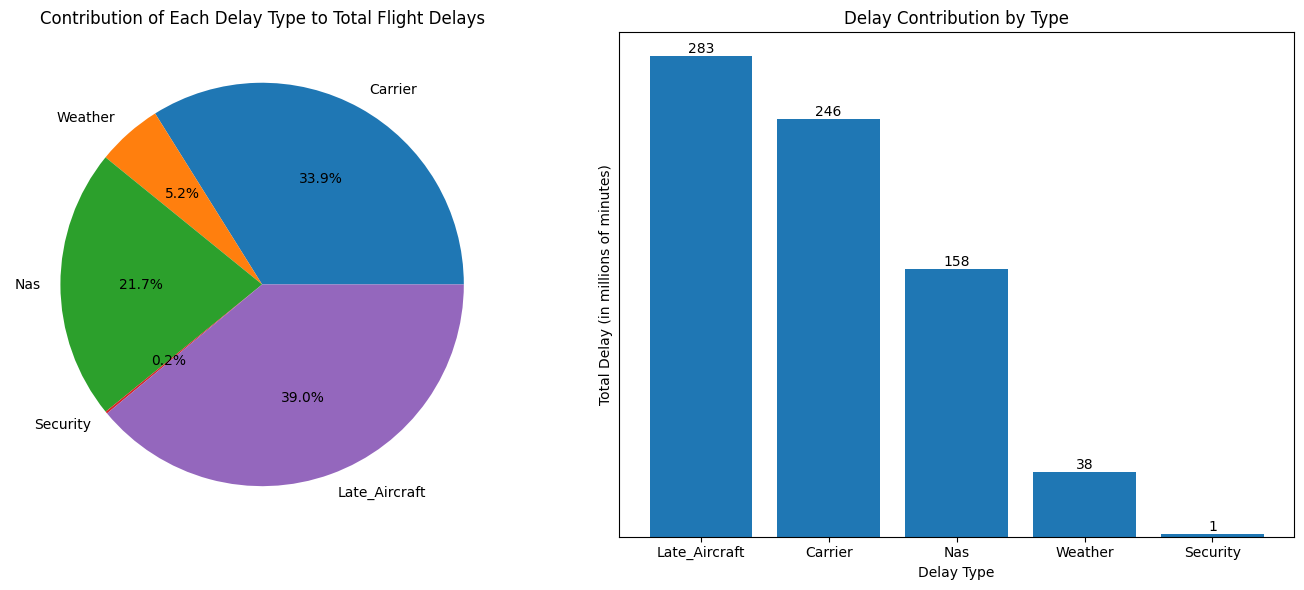

In [33]:
# Sort data for bar chart
delay_df_sorted = delay_df.sort_values(by='Total_Delay', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(
    delay_df['Share'],
    labels=delay_df['Delay_Type'],
    autopct='%1.1f%%'
)
axes[0].set_title("Contribution of Each Delay Type to Total Flight Delays")

# Bar chart (sorted, in millions)
bars = axes[1].bar(
    delay_df_sorted['Delay_Type'],
    delay_df_sorted['Total_Delay'] / 1e6
)

# Add data labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )

# Remove y-axis ticks but keep label
axes[1].set_yticks([])
axes[1].set_xlabel("Delay Type")
axes[1].set_ylabel("Total Delay (in millions of minutes)")
axes[1].set_title("Delay Contribution by Type")

plt.tight_layout()
plt.show()

I used a pie chart to show proportional contribution, but for precise comparison I prefer bar charts — so I included both.

**Insights**
- This analysis highlights which delay sources dominate system-wide delays
- Unlike per-flight analysis, this shows network-level impact
- Late Aircraft Delays often contribute the largest share (39%)→ indicates cascading delays
- Carrier Delays (34%) reflect internal inefficiencies

----

**6.2.4 Delay Cause Contribution Over Time**

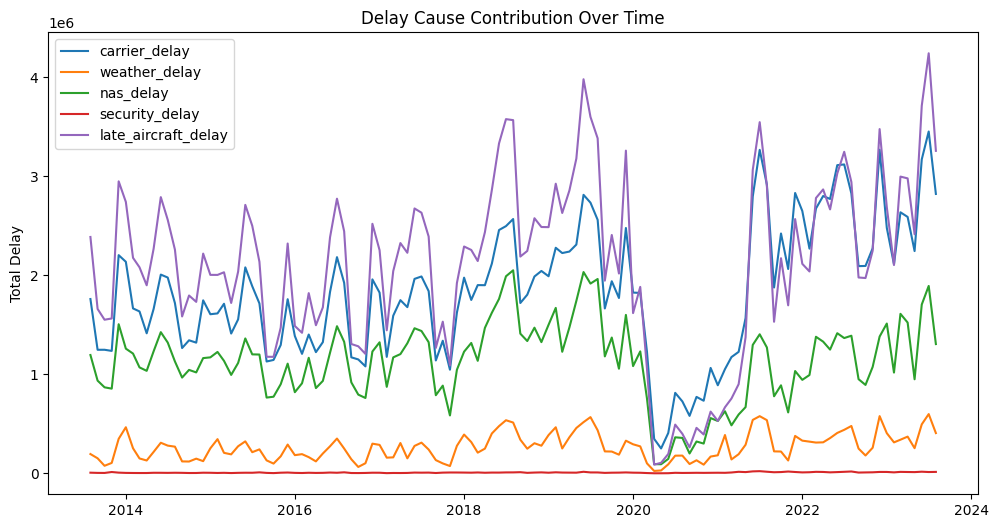

In [34]:
# Use delay_types to dynamically select count columns
delay_cols = [f'{d}_delay' for d in delay_types]

ts_delay = df_winsorized.groupby('date')[delay_cols].sum().reset_index()

plt.figure(figsize=(12,6))

for col in ts_delay.columns[1:]:
    plt.plot(ts_delay['date'], ts_delay[col], label=col)

plt.legend()
plt.title("Delay Cause Contribution Over Time")
plt.ylabel("Total Delay")
plt.show()

**Insight**

Late Aircraft Delay dominance → indicates delay propagation effect i.e. One delay cascades across the network

Carrier Delay consistency → internal airline inefficiencies

Weather spikes → external, unpredictable disruptions

----

## 7. Correlation Analysis

**Objective**

To identify relationships between delay components and total delay

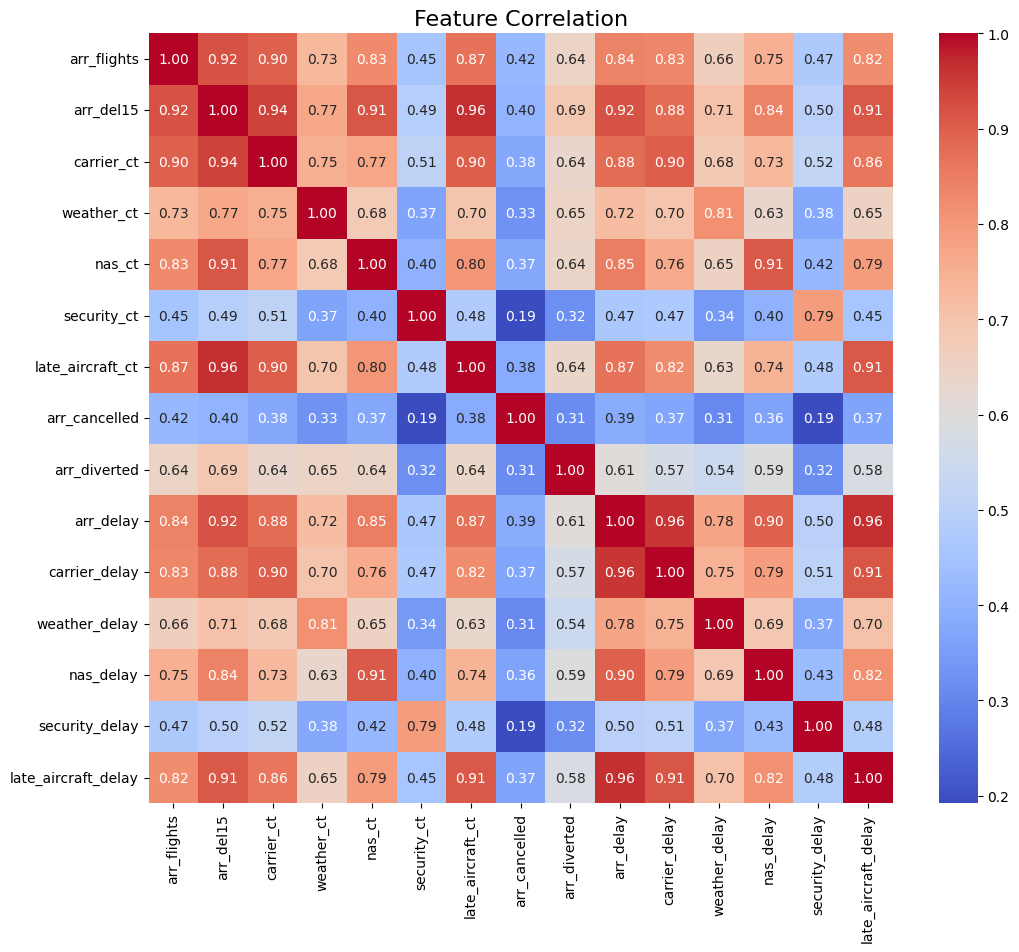

In [35]:
numeric_df = df_winsorized.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(12,10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Feature Correlation', fontsize = 16)
plt.show()

**Observed Strength**

- ~0.8 → strong enough to draw insights
- ≥0.9 → almost redundant / same signal
- ≤0.5 → not reliable relationship

**Insights**

- Strong positive correlation between arr_delay and component delays → (expected decomposition consistency).
- High correlation among some components (e.g., nas_delay, late_aircraft_delay) → possible overlapping operational causes.
- Count-based features (arr_del15, delay counts) show weaker correlation with minutes → frequency ≠ severity, so both must be analyzed separately.

----

## 8. Feature Engineering

**Objective:**

Features were engineered to normalize raw counts and delays into interpretable operational metrics such as rates, shares, and averages.

### 8.1 Rate Calculation

Measures delay intensity relative to total operations.

In [36]:
# -----------------------------
# Rate Calculation
# -----------------------------
# Using the filtered dataset for defining delay Rate calculation
df_winsorized['delay_rate'] = df_winsorized['arr_delay'] / df_winsorized['arr_flights'].replace(0, np.nan)

----

### 8.2 Share of Delay Calculation

Breaks total delay into contributing factors (composition).

In [37]:
# -----------------------------
# Share of Delay Calculation
# -----------------------------
arr_delay_safe = df_winsorized['arr_delay'].replace(0, np.nan)

# Create share columns
for d in delay_types:
    df_winsorized[f'{d}_delay_share'] = df_winsorized[f'{d}_delay'] / arr_delay_safe

----

### 8.3 Frequency Calculation

Normalizes delay counts by total flights (how often delays occur).

In [38]:
# -----------------------------
# Frequency Calculation
# -----------------------------
arr_flights_safe = df_winsorized['arr_flights'].replace(0, np.nan)

# Create frequency columns
for d in delay_types:
    df_winsorized[f'{d}_delay_freq'] = df_winsorized[f'{d}_ct'] / arr_flights_safe

In [39]:
# Overall Frequency
df_winsorized['delay_frequency'] = df_winsorized['arr_del15'] / df_winsorized['arr_flights'].replace(0, np.nan)

----

### 8.4 Severity Calculation

Measures average delay per delayed flight (impact per event).

In [40]:
# -----------------------------
# Severity Calculation
# -----------------------------
for d in delay_types:
    df_winsorized[f'{d}_avg_delay'] = (df_winsorized[f'{d}_delay'] / df_winsorized[f'{d}_ct'].replace(0, np.nan))

In [41]:
# Overall severity
df_winsorized['avg_delay_per_delayed_flight'] = df_winsorized['arr_delay'] / df_winsorized['arr_del15'].replace(0, np.nan)

----

## Creating a filtered Dataset

A filtered dataset will be used for showing visualizations for delay minutes and its derived features.

Reason - Zero delay will not add value to the root cause analysis of delays. 

In [42]:
# Create dataset with only delayed flights
df_delay = df_winsorized[df_winsorized['arr_del15'] > 0].copy()

# Optional sanity check
print("Original dataset shape with engineered features:", df_winsorized.shape)
print("Delayed flights dataset shape:", df_delay.shape)

Original dataset shape with engineered features: (171426, 40)
Delayed flights dataset shape: (164638, 40)


----

## 9. Feature-Driven Analysis

### 9.1 Efficiency Analysis

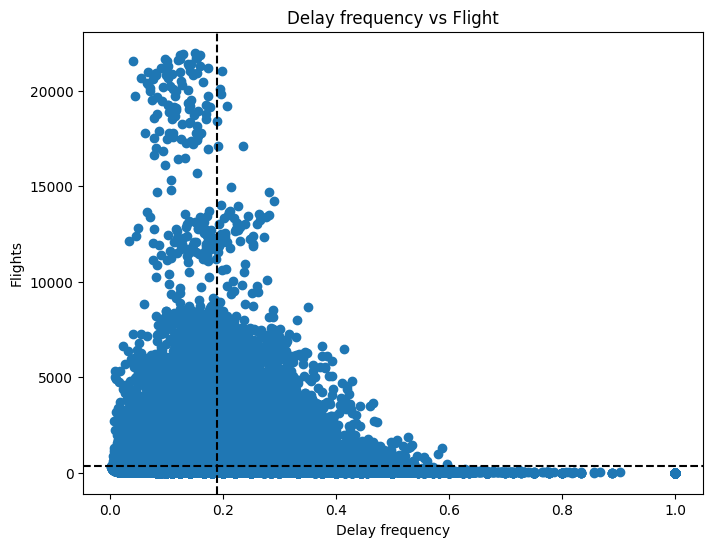

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(df_delay['delay_frequency'], df_delay['arr_flights'])

# Mean lines (quadrants)
plt.axvline(df_delay['delay_frequency'].mean(), linestyle='--', color = 'black')
plt.axhline(df_delay['arr_flights'].mean(), linestyle='--', color = 'black')

plt.xlabel("Delay frequency")
plt.ylabel("Flights")
plt.title("Delay frequency vs Flight")

plt.show()

**Insights**

High rate + low flights → inefficiency

Low rate + high flights → efficiency

----

### 9.2 Share Analysis (Composition)

**Objective**

To break down total flight delays into their root causes and understand how each factor contributes to overall delay patterns.

**Methodology**

The dataset follows the Bureau of Transportation Statistics (BTS) delay classification:

Carrier Delay → Airline operational issues  
Weather Delay → Severe weather conditions  
NAS Delay → Air traffic & airport congestion  
Security Delay → Security-related disruptions  
Late Aircraft Delay → Delay propagated from previous flights  
These components are mutually exclusive, meaning:

Total Arrival Delay ≈ Sum of all delay components

Showing data distribution for Share features

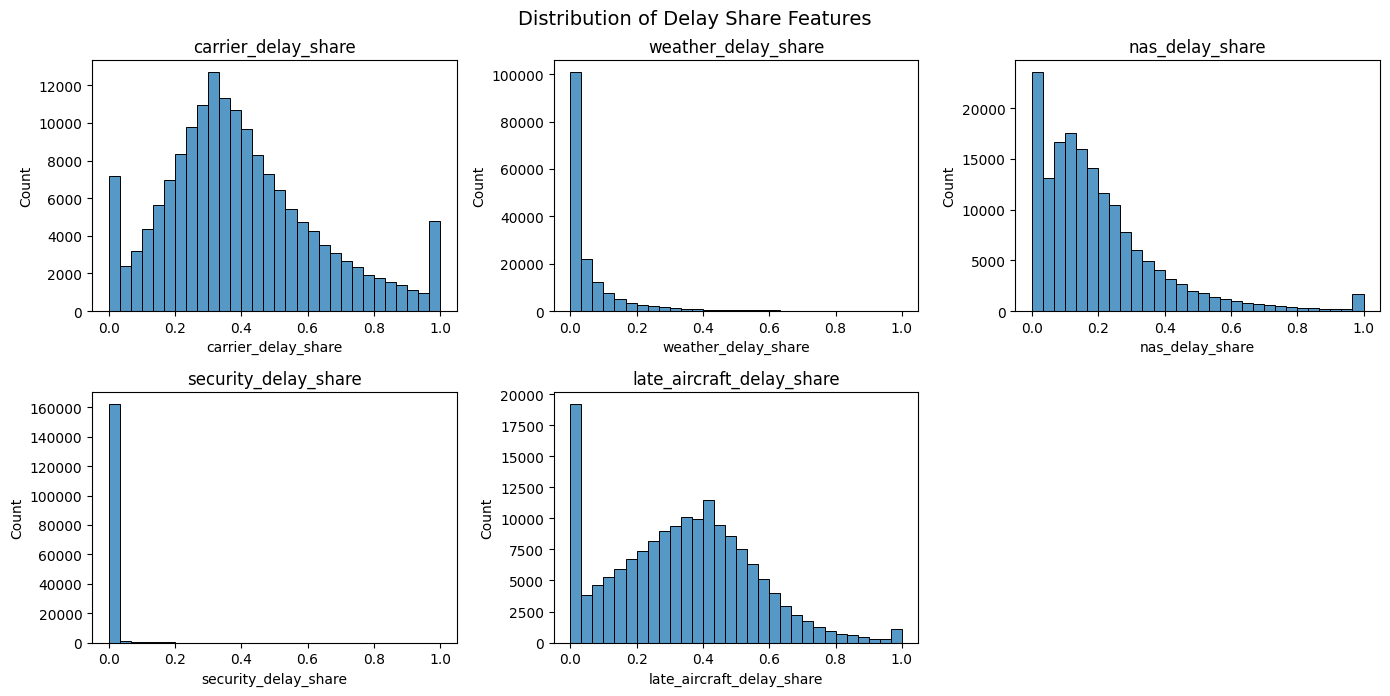

In [44]:
share_features = ['carrier_delay_share', 'weather_delay_share', 'nas_delay_share', 'security_delay_share', 'late_aircraft_delay_share']

fig, axes = plt.subplots(3, 3, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(share_features):
    sns.histplot(df_delay[col], bins=30, ax=axes[i])
    axes[i].set_title(col)

# Hide extra plots
for j in range(len(share_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Delay Share Features", fontsize=14)
plt.tight_layout()
plt.show()

Showing share of each delay by date

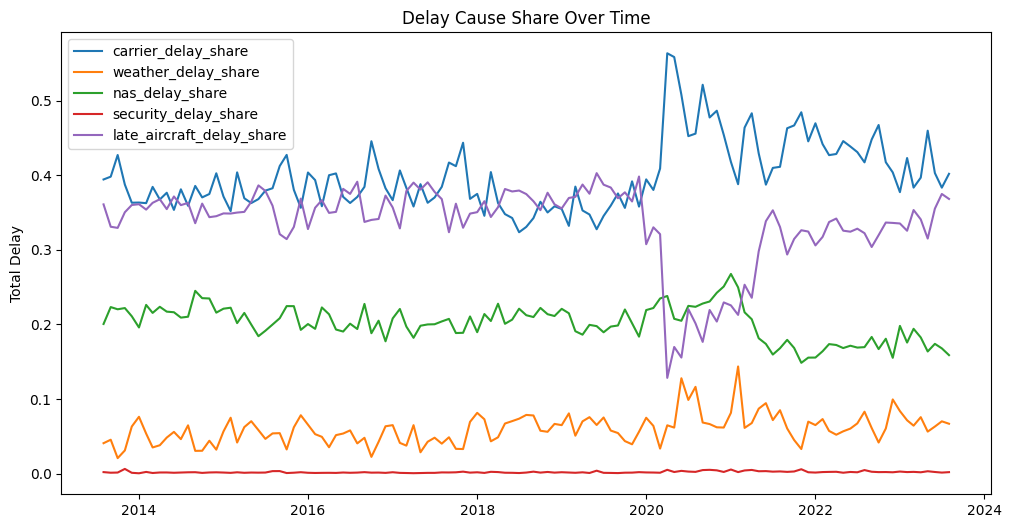

In [45]:
ts = df_delay.groupby('date')[share_features].mean().reset_index()

plt.figure(figsize=(12,6))

for col in ts.columns[1:]:
    plt.plot(ts['date'], ts[col], label=col)

plt.legend()
plt.title("Delay Cause Share Over Time")
plt.ylabel("Total Delay")
plt.show()

Showing Monthly Flight Volume Trend

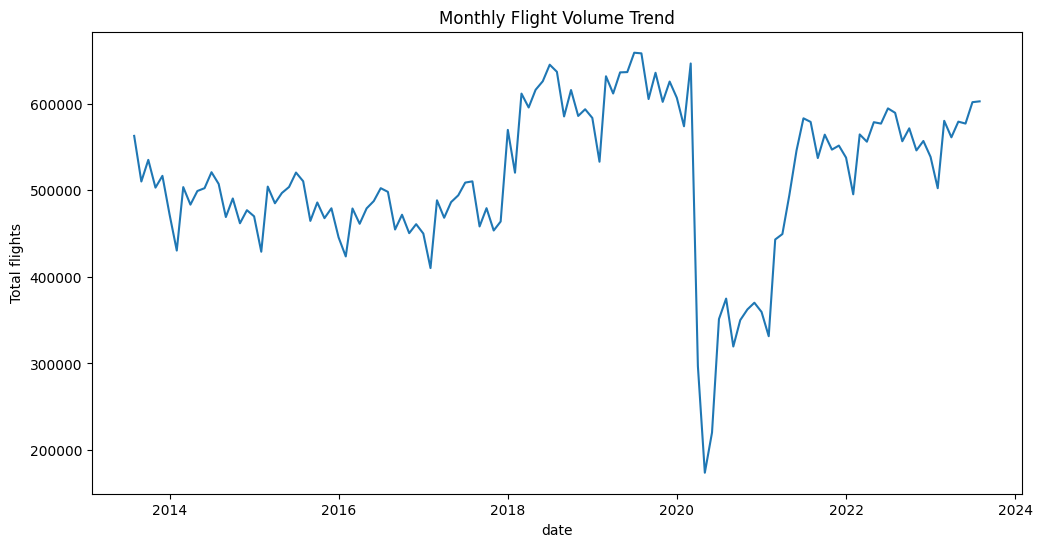

In [46]:
ts = df_delay.groupby('date')['arr_flights'].sum().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(data=ts, x='date', y='arr_flights')

plt.title("Monthly Flight Volume Trend")
plt.ylabel("Total flights")
plt.show()

**Insights**

- Carrier delay is the highest cause of delay showing inefficiency.
- Carrier delay and Late aircraft delays show similar patterns until pandemic.
- During pandenmic it is interesting to note that carrier delay rose while late aircraft delays fell due to less everall flights but higher staff inefficiency or absence (further study required)
- NAS delays after showing spike in 2021, have dropped off to a lower value maybe due to less overall aircrafts

----

### 9.3 Frequency vs Severity Analysis

### Objective
To identify which types of delays are most critical by analyzing:
- How frequently they occur
- How severe their impact is in terms of delay duration

### Methodology
Two key metrics were derived:
- Frequency = Delay Count / Total Flights
- Severity = Total Delay Minutes / Delay Count

This allows classification of delay types into operational risk categories.

Interpretation Framework

| Quadrant                       | Meaning                    | Action                    |
| ------------------------------ | -------------------------- | ------------------------- |
| High Frequency + High Severity | Critical Issues            | Immediate action required |
| High Frequency + Low Severity  | Operational inefficiencies | Process optimization      |
| Low Frequency + High Severity  | Rare but impactful         | Contingency planning      |
| Low Frequency + Low Severity   | Minor issues               | Low priority              |

In [47]:
# -----------------------------
# Aggregate for matrix (mean)
# -----------------------------
matrix_df = pd.DataFrame({
    'Delay_Type': ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft'],
    'Frequency': [df_winsorized[f'{d}_delay_freq'].mean() for d in delay_types],
    'Severity': [df_winsorized[f'{d}_avg_delay'].mean() for d in delay_types]
})

matrix_df

,Delay_Type,Frequency,Severity
0,Carrier,0.067412,63.980565
1,Weather,0.007956,94.225161
2,NAS,0.049056,43.458936
3,Security,0.000464,48.047700
4,Late Aircraft,0.058262,68.098719


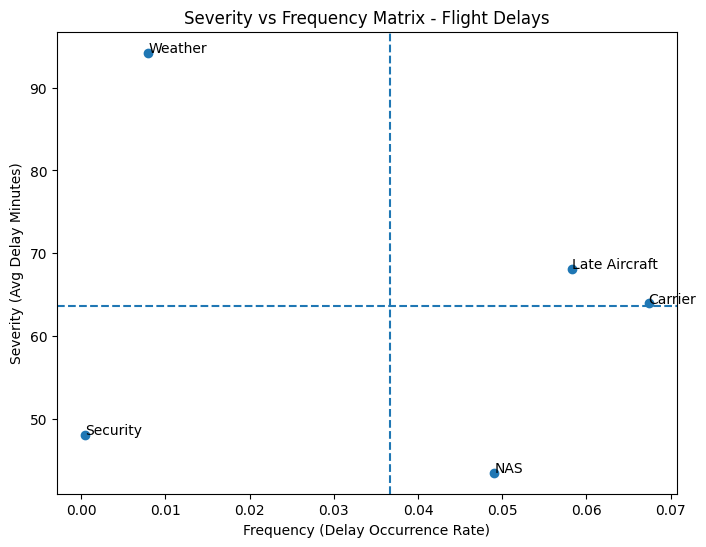

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(matrix_df['Frequency'], matrix_df['Severity'])

for i, txt in enumerate(matrix_df['Delay_Type']):
    plt.annotate(txt, (matrix_df['Frequency'][i], matrix_df['Severity'][i]))

# Mean lines (quadrants)
plt.axvline(matrix_df['Frequency'].mean(), linestyle='--')
plt.axhline(matrix_df['Severity'].mean(), linestyle='--')

plt.xlabel("Frequency (Delay Occurrence Rate)")
plt.ylabel("Severity (Avg Delay Minutes)")
plt.title("Severity vs Frequency Matrix - Flight Delays")

plt.show()

Showing Overall Severity vs Frequency Matrix

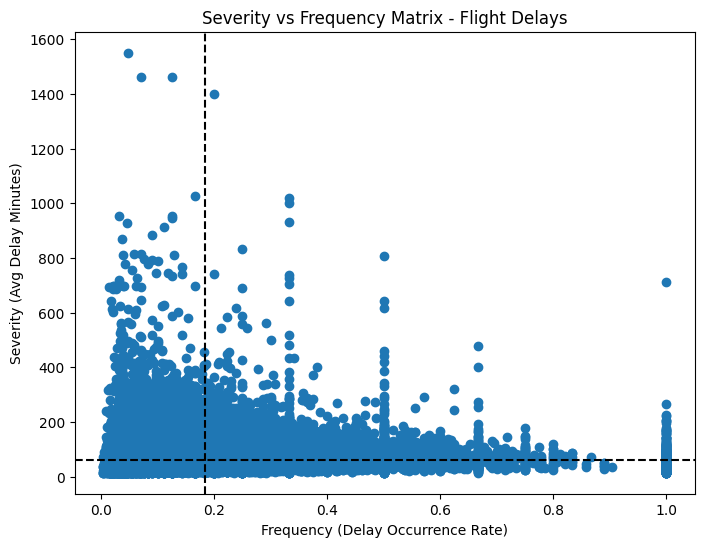

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(df_winsorized['delay_frequency'], df_winsorized['avg_delay_per_delayed_flight'])

# Mean lines (quadrants)
plt.axvline(df_winsorized['delay_frequency'].mean(), linestyle='--', color = 'black')
plt.axhline(df_winsorized['avg_delay_per_delayed_flight'].mean(), linestyle='--', color = 'black')

plt.xlabel("Frequency (Delay Occurrence Rate)")
plt.ylabel("Severity (Avg Delay Minutes)")
plt.title("Severity vs Frequency Matrix - Flight Delays")

plt.show()

**Insights**

- Late Aircraft Delays often fall into high frequency, indicating scheduling inefficiencies.
- Weather Delays tend to be low frequency but high severity, making them unpredictable but impactful.
- Carrier Delays indicate internal operational inefficiencies.
- Security Delays are typically low frequency and low severity.

----

## 10. Time Series Analysis

### 10.1 Delay rate over time

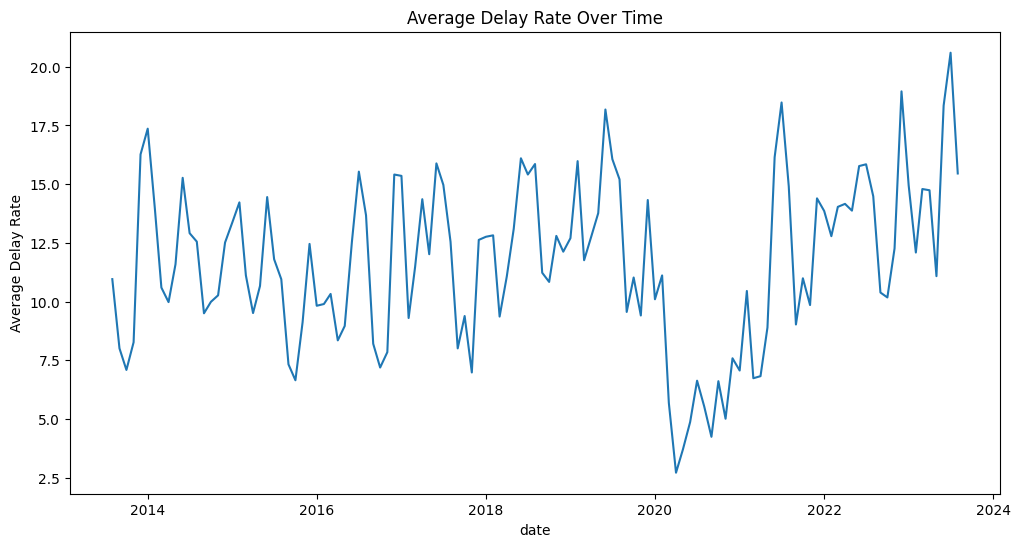

In [50]:
ts = df_delay.groupby('date')['delay_rate'].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(data=ts, x='date', y='delay_rate')

plt.title("Average Delay Rate Over Time")
plt.ylabel("Average Delay Rate")
plt.show()

**Insights**

- The 2020 drop likely reflects reduced air traffic during COVID → fewer delays due to lower congestion
- Post-pandemic recovery shows: Increased demand and Strained operations → higher delays

----

### 10.2 Flight Disruption Counts over time

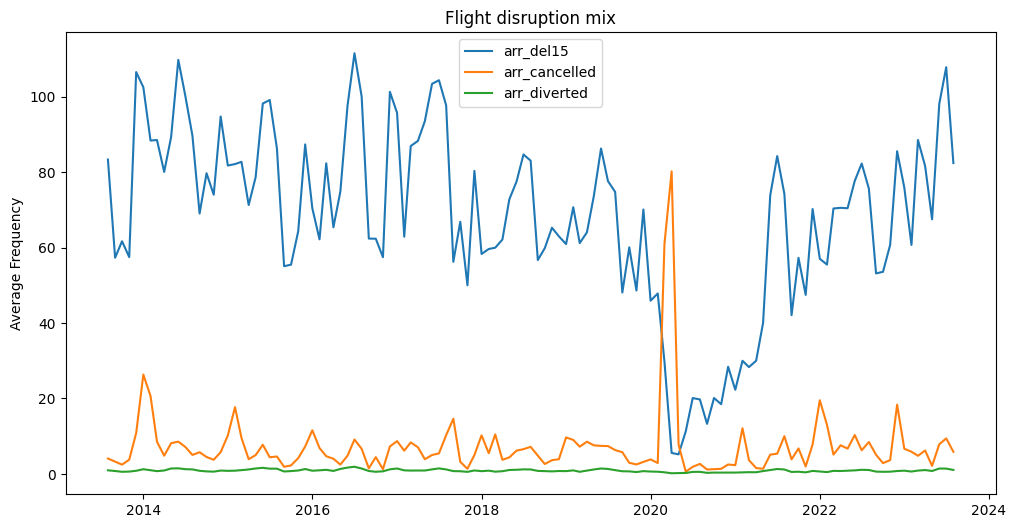

In [51]:
ts = df_winsorized.groupby('date')[[
    'arr_del15',
    'arr_cancelled',
    'arr_diverted'
]].mean().reset_index()

plt.figure(figsize=(12,6))

for col in ts.columns[1:]:
    plt.plot(ts['date'], ts[col], label=col)

plt.legend()
plt.title("Flight disruption mix")
plt.ylabel("Average Frequency")
plt.show()

**Insights**

- 2020 dip in delays and spike in cancellations are linked to the pandemic.
- Other spikes are connected to seasonal patterns and weather disruptions.

----

### 10.3 Seasonal Delay Pattern (Month-wise)

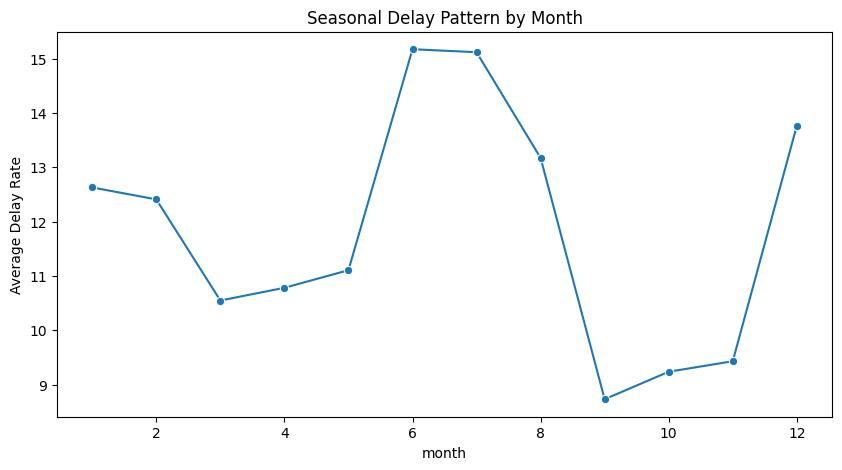

In [52]:
seasonal = (
    df_delay
    .groupby('month', observed=False)['delay_rate'].mean().reset_index()
)
plt.figure(figsize=(10,5))

sns.lineplot(data=seasonal, x='month', y='delay_rate', marker='o')

plt.title("Seasonal Delay Pattern by Month")
plt.ylabel("Average Delay Rate")
plt.show()

**Insights**

- Summer peak → high travel demand → congestion (Jun-Aug)
- Winter increase → weather disruptions (Dec-Feb)
- Low-delay window → shoulder seasons (Sept–Oct)

----

### 10.4 Weather Impact on Cancellations

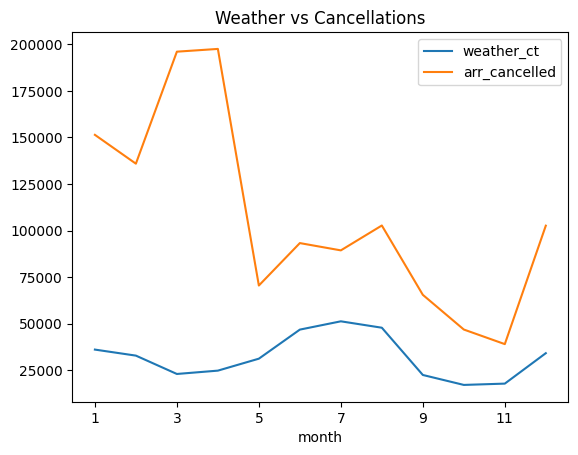

In [53]:
weather_cancel = (
    df_winsorized
    .groupby('month', observed=False)[['weather_ct','arr_cancelled']].sum().reset_index()
)
weather_cancel.plot(x='month')

plt.title("Weather vs Cancellations")
plt.show()

**Insights**

- Strong correlation between weather delays and cancellations → Winter Peak
- Weather = root cause of extreme disruptions

----

## 11. Airline Performance Analysis

### 11.1 Airline Delay Rate

**Airline Delay Performance (Average Delay Rate)**

Average proportion of flights delayed (≥15 min) for each airline.

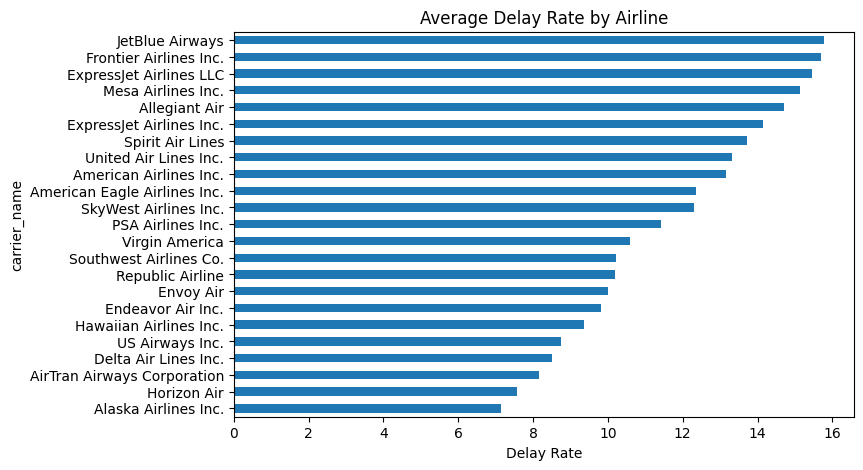

In [54]:
airline_perf = df_delay.groupby('carrier_name')['delay_rate'].mean().sort_values()

airline_perf.plot(kind='barh', figsize=(8,5))

plt.title("Average Delay Rate by Airline")
plt.xlabel("Delay Rate")
plt.show()

**Insights**

- Significant variation exists across airlines, indicating uneven operational efficiency in the industry.
- Airlines at the top (e.g., JetBlue, Frontier) consistently report higher delay rates, suggesting systemic inefficiencies.
- Lower-ranked airlines (e.g., Alaska, Horizon) demonstrate better schedule adherence and operational control.

**Note -** While average delay rate measures efficiency, variability reveals reliability — both are essential to evaluate overall airline performance.

----

### 11.2 Airline Delay Consistency

**Airline Reliability (Delay Rate Volatility)**

Standard deviation of delay rate, capturing consistency of performance over time.

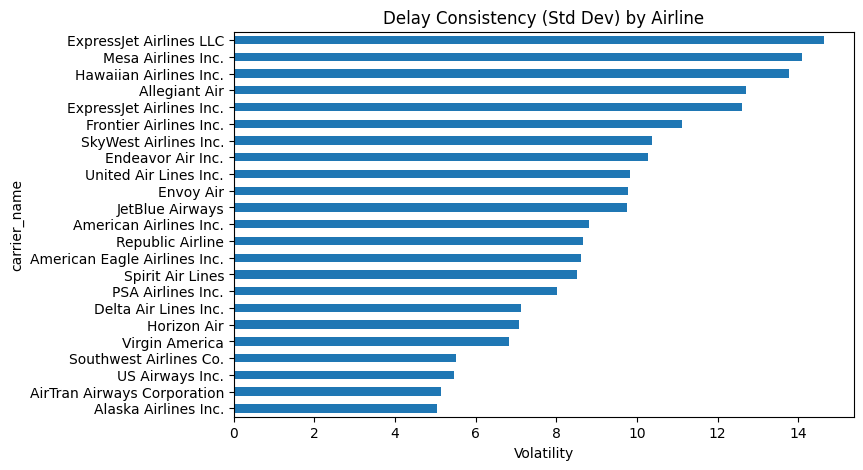

In [55]:
airline_var = df_winsorized.groupby('carrier_name')['delay_rate'].std().sort_values()

airline_var.plot(kind='barh', figsize=(8,5))

plt.title("Delay Consistency (Std Dev) by Airline")
plt.xlabel("Volatility")
plt.show()

**Insights**

- High variability airlines (e.g., ExpressJet, Mesa) experience frequent fluctuations, indicating unstable operations.
- Low variability airlines (e.g., Alaska, AirTran) maintain consistent performance, even if not always the best.
- Consistency varies independently of average delay, highlighting that reliability and efficiency are distinct dimensions.

----

### 11.3 Airline Performance Matrix

**Objective**

To evaluate airline performance using two key dimensions:

Efficiency → measured by average delay rate
Consistency → measured by variability (standard deviation) of delay rate

This helps identify not just how delayed an airline is, but also how reliably it performs over time.

**Methodology**

Aggregated delay performance at the airline level using:
- Mean Delay Rate → average operational efficiency
- Standard Deviation of Delay Rate → performance consistency

Each airline is represented as a point in a 2D space:
- X-axis → Average Delay Rate
- Y-axis → Standard Deviation (Volatility)
This creates a performance matrix for comparative analysis.

**Interpretation Framework**

Airlines are classified into four categories:

| Quadrant             | Characteristics        | Interpretation          |
| -------------------- | ---------------------- | ----------------------- |
| Low Mean + Low Std   | Efficient & Stable     | Best performers         |
| Low Mean + High Std  | Efficient but Unstable | Risky but promising     |
| High Mean + Low Std  | Consistently Poor      | Structural inefficiency |
| High Mean + High Std | Poor & Unstable        | Worst performers        |


In [56]:
# generates airline_summary_table with mean and standard deviation columns
airline_summary_matrix = df_winsorized.groupby('carrier_name')['delay_rate'].agg(['mean','std'])
airline_summary_matrix.sort_values('mean')

,mean,std
carrier_name,,
Alaska Airlines Inc.,6.912770,5.029405
Horizon Air,7.242888,7.069337
AirTran Airways Corporation,7.990659,5.144205
Delta Air Lines Inc.,8.281838,7.119491
US Airways Inc.,8.528214,5.455465
Hawaiian Airlines Inc.,9.183258,13.783337
Endeavor Air Inc.,9.185058,10.267358
Republic Airline,9.282027,8.664945
Envoy Air,9.525356,9.786915


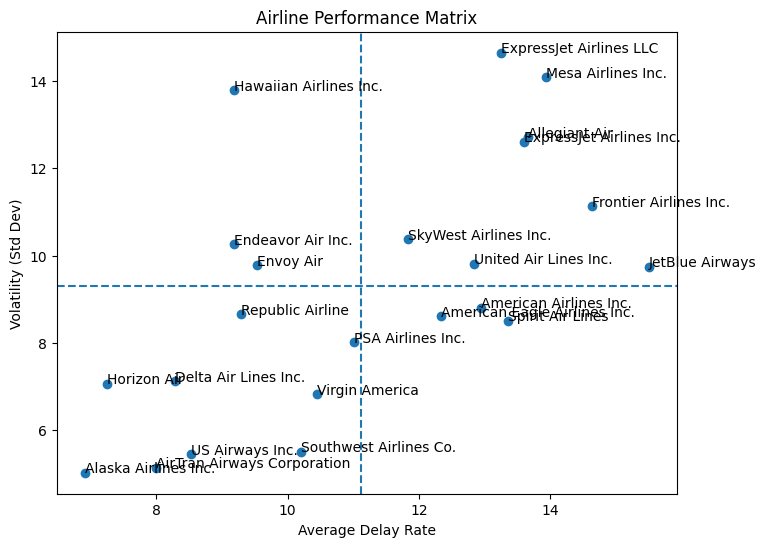

In [57]:
plt.figure(figsize=(8,6))

plt.scatter(airline_summary_matrix['mean'], airline_summary_matrix['std'])

for i in airline_summary_matrix.index:
    plt.text(airline_summary_matrix.loc[i,'mean'], airline_summary_matrix.loc[i,'std'], i)

plt.axvline(airline_summary_matrix['mean'].mean(), linestyle='--')
plt.axhline(airline_summary_matrix['std'].mean(), linestyle='--')

plt.xlabel("Average Delay Rate")
plt.ylabel("Volatility (Std Dev)")
plt.title("Airline Performance Matrix")

plt.show()

**Insights**

1. Clear Performance Segmentation
- Airlines naturally cluster into distinct performance groups
- Not all high-delay airlines are unstable → some are consistently inefficient

2. Consistency vs Efficiency Trade-off
- Some airlines show:
  - Low average delay but high volatility
    → Indicates operational instability
- Others show:
  - Higher delay but low variability
    → Indicates predictable but inefficient systems

3. Identification of Reliable Airlines
- Airlines with low mean and low variance:
  - Provide consistent service
  - Are operationally well-managed
  - Likely better at scheduling and turnaround

4. Risk Identification
- High volatility airlines:
    → Experience frequent spikes in delays
- Likely impacted by:
  - Poor planning
  - Network sensitivity
  - External disruptions

----

### 11.4 Cancellation Rate

In [58]:
df_winsorized['cancel_rate'] = df_winsorized['arr_cancelled']/df_winsorized['arr_flights']

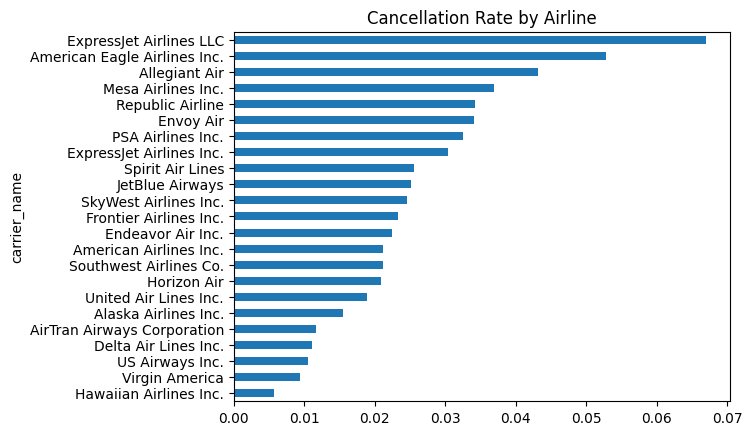

In [59]:
airline_cancel = df_winsorized.groupby('carrier_name')['cancel_rate'].mean().sort_values()

airline_cancel.plot(kind='barh')

plt.title("Cancellation Rate by Airline")
plt.show()

**Insights**

- Some airlines cancel more → operational strategy or inefficiency
- Low cancellation airlines may have:
- Better planning, More buffers

----

### 11.4 ImPax% - Severe Disruption Risk

**Objective**
--> To calculate Sever Disruption Risk

**Definition**
--> Impax% is the percentage of passengers impacted by disruptions.

**Formula**
--> ImPax% = (Number of Flights delayed > 60 min + Cancelled flights) / Planned flights

In [60]:
df_impax = df_winsorized.copy()

# Severe delay flag (>60 min)
df_impax['severe_delay_flag'] = df_impax['avg_delay_per_delayed_flight'] > 60

# Estimate severe delay flights
df_impax['severe_delay_flights'] = df_impax['severe_delay_flag'] * df_impax['arr_del15']

# Group by airline (carrier or carrier_name)
impax_airline = df_impax.groupby('carrier_name').agg({
    'severe_delay_flights': 'sum',
    'arr_cancelled': 'sum',
    'arr_flights': 'sum'
}).reset_index()

# ImPax %
impax_airline['impax_%'] = (
    (impax_airline['severe_delay_flights'] + impax_airline['arr_cancelled']) 
    / impax_airline['arr_flights']
) * 100

# Sort (optional)
impax_airline = impax_airline.sort_values(by='impax_%', ascending=False)

impax_airline

,carrier_name,severe_delay_flights,arr_cancelled,arr_flights,impax_%
2,Allegiant Air,109832.0,24303.0,613357.0,21.868993
9,ExpressJet Airlines LLC,24162.0,8198.0,149234.0,21.684067
10,Frontier Airlines Inc.,221710.0,22063.0,1158943.0,21.034080
19,Spirit Air Lines,244802.0,34307.0,1526076.0,18.289325
14,Mesa Airlines Inc.,134447.0,30366.0,914298.0,18.026180
13,JetBlue Airways,387498.0,59509.0,2609697.0,17.128693
8,ExpressJet Airlines Inc.,325087.0,85844.0,2637669.0,15.579324
16,Republic Airline,184860.0,55345.0,1717781.0,13.983447
15,PSA Airlines Inc.,136204.0,43897.0,1326337.0,13.578826
17,SkyWest Airlines Inc.,727460.0,138798.0,6905056.0,12.545271


**Airline Impax% Chart**

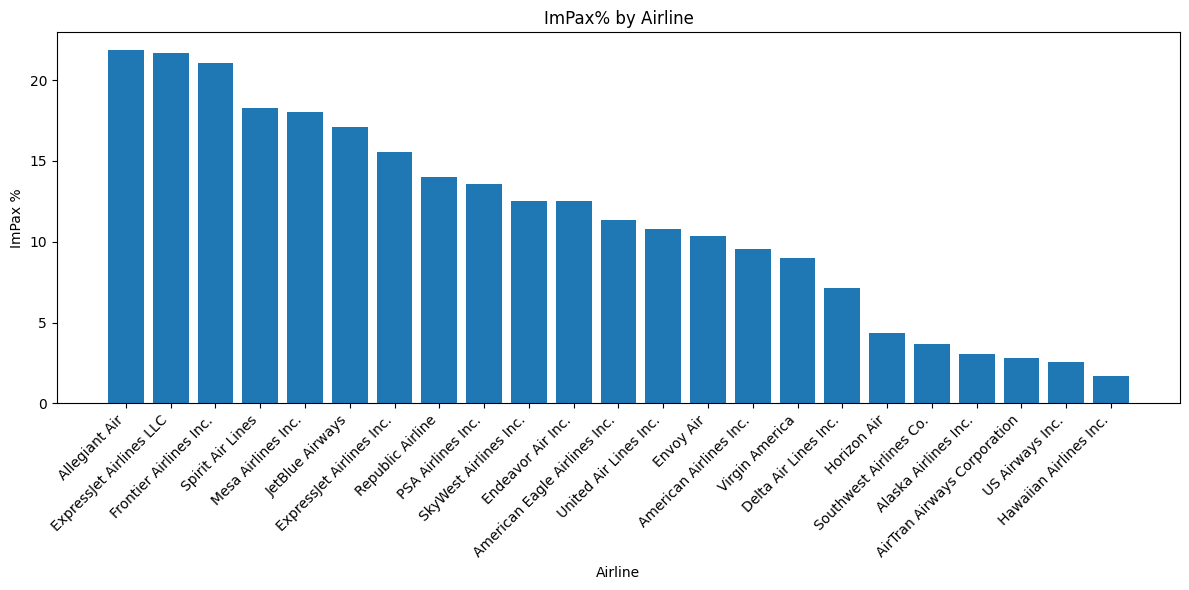

In [61]:
impax_airline_sorted = impax_airline.sort_values(by='impax_%', ascending=False)

# Plot
plt.figure(figsize=(12,6))

plt.bar(impax_airline_sorted['carrier_name'], impax_airline_sorted['impax_%'])

plt.title("ImPax% by Airline")
plt.xlabel("Airline")
plt.ylabel("ImPax %")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Insights**

Since the risk metric combines cancellations and delays, higher the Impax% of an airline higher is the flight disruption risk.

- Allegiant, Expressjet and Frontier Air have Impax% of above 20% - Very High Risk
- Spirit, MESA, JetBlue and Expressjet inc. have Impax% between 15 to 20% - High Risk
- Horizon, Southwest, Alaska, Airtrain, US airways and Hawaiian have Impax% below 5% - Low Risk

----

### 11.5 Monthly Heatmap

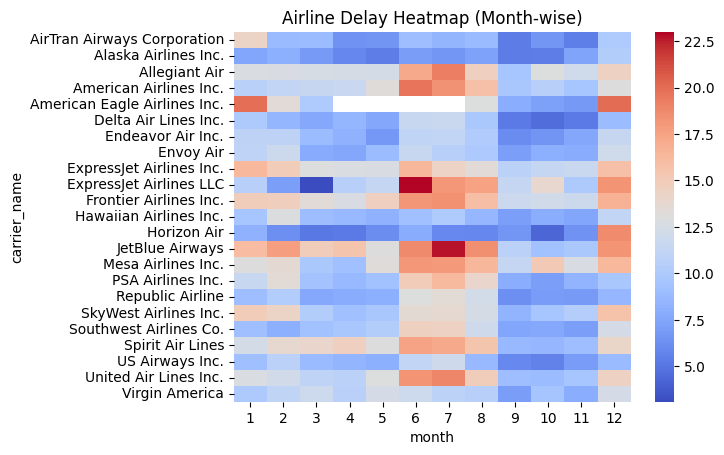

In [62]:
pivot = df_winsorized.pivot_table(
    values='delay_rate',
    index='carrier_name',
    columns='month',
    aggfunc='mean',
    observed = True
)

sns.heatmap(pivot, cmap='coolwarm')

plt.title("Airline Delay Heatmap (Month-wise)")
plt.show()

### Insights
Heatmap clearly shows the operational delay characteristics of each airline by month.

----

## 12. Key Performance Indicators (KPI)

### 12.1 On-time performance (OTP)

Objective - To quantify the proportion of flights that are delayed versus those that operate on time.

Methodology - Flights with recorded delay components were classified as Delayed Flights. Flights with no delay records were classified as On-Time Flights

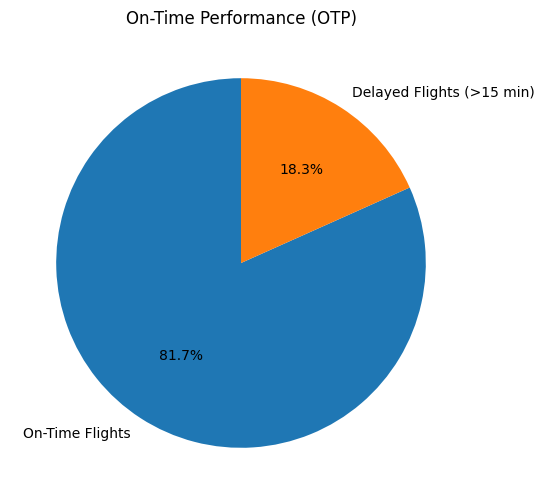

In [63]:
plt.figure(figsize=(6,6))

plt.pie(
    [
        df_winsorized['arr_flights'].sum() - df_winsorized['arr_del15'].sum(),
        df_winsorized['arr_del15'].sum()
    ],
    labels=['On-Time Flights', 'Delayed Flights (>15 min)'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("On-Time Performance (OTP)")
plt.show()

In [64]:
otp = (df_winsorized['arr_flights'].sum() - df_winsorized['arr_del15'].sum()) / df_winsorized['arr_flights'].sum() * 100
print(f"OTP: {otp:.2f}%")

OTP: 81.70%


In [65]:
# Copy dataset
df_kpi = df_winsorized.copy()

**Key Findings**

On-time Performance 81.7%.

**Insights**

The system shows moderate delay prevalence, indicating:
- Network congestion
- Operational inefficiencies
- Delay propagation effects

----

### 12.2 Cancellation Rate %

In [66]:
# Code to find overall cancellation rate
print(f"Overall flight cancellation rate: {df_winsorized['cancel_rate'].mean() * 100}")

Overall flight cancellation rate: 2.4822047610815234


----

### 12.3 ImPax% (Approximation)

In [67]:
# Code for ImPax% (Approximation)

# totals
severe_delays = df_impax['severe_delay_flights'].sum()
cancelled = df_impax['arr_cancelled'].sum()
planned = df_impax['arr_flights'].sum()

# ImPax %
impax = (severe_delays + cancelled) / planned * 100

print(f"ImPax% (approx): {impax:.2f}%")

ImPax% (approx): 9.64%


**Insights**

An overall Impax% of 9.64% for the time period of this dataset is consistent with Impax report for North America.

source - https://impax.aero/report.html

----

### 12.4 Disruption Score

Objective
To extend delay analysis by incorporating cancellations and diversions for a complete view of operational disruptions.

**Version 1: Business Weighted Score**

A custom disruption index was created by assigning higher weights to more severe operational events.

**Business Assumption based Impact**

- Cancellations → highest disruption (weight = 5)
- Diversions → moderate disruption (weight = 3)
- Delays → baseline operational inefficiency

In [68]:
df_kpi = df_winsorized.copy()

df_kpi['delay_rate'] = df_kpi['arr_del15'] / df_kpi['arr_flights'].replace(0, np.nan)
df_kpi['cancel_rate'] = df_kpi['arr_cancelled'] / df_kpi['arr_flights'].replace(0, np.nan)
df_kpi['divert_rate'] = df_kpi['arr_diverted'] / df_kpi['arr_flights'].replace(0, np.nan)

df_kpi['disruption_score'] = (
    df_kpi['delay_rate'] +
    5 * df_kpi['cancel_rate'] +
    3 * df_kpi['divert_rate']
)

In [69]:
print(f"Disruption Score based on Business Assumption: {df_kpi['disruption_score'].mean()}")

Disruption Score based on Business Assumption: 0.31579505486546094


**Disruption Mix**

This shows the composition of disruption types across all flights.

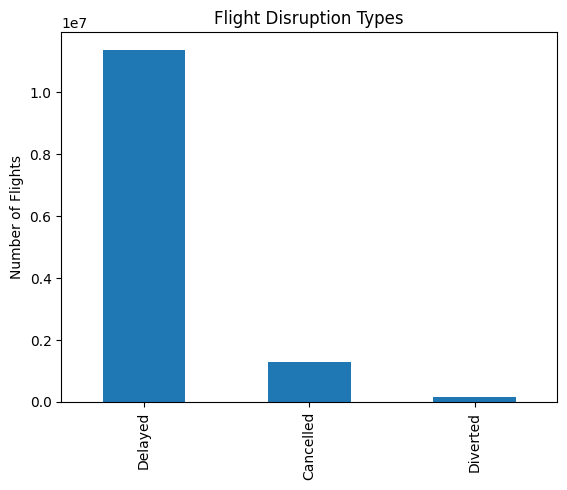

In [70]:
disruption = {
    'Delayed': df_winsorized['arr_del15'].sum(),
    'Cancelled': df_winsorized['arr_cancelled'].sum(),
    'Diverted': df_winsorized['arr_diverted'].sum()
}

pd.Series(disruption).plot(kind='bar')

plt.title("Flight Disruption Types")
plt.ylabel("Number of Flights")
plt.show()

----

## 13. Airline Summary table

In [71]:
# Code to create airline summary table
df_final = df_winsorized.copy()

# Bring in features (aligned by index)
df_final['severe_delay_flights'] = df_impax['severe_delay_flights']
df_final['disruption_score'] = df_kpi['disruption_score']

# Aggregate to airline level
airline_kpi = df_final.groupby('carrier_name').agg({
    'arr_flights': 'sum',
    'arr_del15': 'sum',
    'arr_cancelled': 'sum',
    'severe_delay_flights': 'sum',
    'cancel_rate': 'mean',
    'disruption_score': 'mean',
}).reset_index()

# Cancel Rate

# Convert cancel_rate to percentage
airline_kpi['cancel_rate'] = airline_kpi['cancel_rate'] * 100

# OTP
airline_kpi['OTP_%'] = (
    (airline_kpi['arr_flights'] - airline_kpi['arr_del15'] - airline_kpi['arr_cancelled'])
    / airline_kpi['arr_flights']
) * 100

# ImPax%
airline_kpi['ImPax_%'] = (
    (airline_kpi['severe_delay_flights'] + airline_kpi['arr_cancelled'])
    / airline_kpi['arr_flights']
) * 100

# Final table
airline_kpi = airline_kpi[[
    'carrier_name',
    'arr_flights',
    'arr_del15',
    'arr_cancelled',
    'severe_delay_flights',
    'cancel_rate',
    'OTP_%',
    'ImPax_%',
    'disruption_score',
]].sort_values(by='disruption_score', ascending=False).reset_index(drop=True)

airline_kpi

,carrier_name,arr_flights,arr_del15,arr_cancelled,severe_delay_flights,cancel_rate,OTP_%,ImPax_%,disruption_score
0,ExpressJet Airlines LLC,149234.0,29672.0,8198.0,24162.0,6.701290,74.623745,21.684067,0.525047
1,American Eagle Airlines Inc.,279283.0,61132.0,15074.0,16667.0,5.286603,72.713699,11.365174,0.504820
2,Allegiant Air,613357.0,149943.0,24303.0,109832.0,4.318821,71.591422,21.868993,0.433233
3,Mesa Airlines Inc.,914298.0,170060.0,30366.0,134447.0,3.697353,78.078701,18.026180,0.376114
4,JetBlue Airways,2609697.0,647919.0,59509.0,387498.0,2.519840,72.892332,17.128693,0.371583
5,ExpressJet Airlines Inc.,2637669.0,540578.0,85844.0,325087.0,3.034533,76.250925,15.579324,0.367118
6,Envoy Air,2073685.0,394625.0,74306.0,139931.0,3.411569,77.386585,10.331222,0.356740
7,PSA Airlines Inc.,1326337.0,231648.0,43897.0,136204.0,3.253814,79.225114,13.578826,0.348990
8,Frontier Airlines Inc.,1158943.0,291403.0,22063.0,221710.0,2.333438,72.952423,21.034080,0.348514
9,Spirit Air Lines,1526076.0,330708.0,34307.0,244802.0,2.551800,76.081466,18.289325,0.336083


**Key Insights from Airline KPI Table**

1. Severe Underperformers (High Disruption + Low OTP)
   - ExpressJet Airlines LLC and American Eagle Airlines Inc. show the highest disruption scores (>0.50)
   - Their OTP is among the lowest (~72–75%)
   - High ImPax% (11–21%) indicates significant passenger impact

Insight:

These airlines suffer from both frequent and severe disruptions, indicating structural operational inefficiencies.

2. High Passenger Impact Despite Moderate Disruption
   - Allegiant Air and Frontier Airlines Inc.
   - Disruption score is moderate (~0.34–0.43)
   - But ImPax% is very high (~21%)

Insight:

Delays may not always be frequent, but when they occur, they are highly severe, causing disproportionate passenger impact.

3. Balanced but Risky Mid-Tier Airlines
   - JetBlue Airways, Spirit Air Lines, Mesa Airlines Inc.
   - Moderate disruption (~0.33–0.37)
   - OTP ~72–78%
   - ImPax% still high (~17–18%)

Insight:

These airlines operate at moderate efficiency but carry consistent disruption risk, making them unstable performers.

4. Strong Performers (Low Disruption + High OTP)
   - Delta Air Lines Inc., Hawaiian Airlines Inc., Alaska Airlines Inc.
   - Lowest disruption scores (~0.19–0.24)
   - Highest OTP (82–87%)
   - Very low ImPax% (<7%)

Insight:

These airlines demonstrate high operational efficiency and reliability, with minimal passenger disruption.

5. Hidden Insight: OTP Alone is Misleading
   - Southwest Airlines Co.
   - OTP ~78% (looks decent)
   - But very low ImPax% (~3.7%)
   - Allegiant Air
   - Similar OTP (~71%)
   - But ImPax% ~21% (!!)

Insight:

Similar OTP does not imply similar passenger experience — severity matters, not just frequency.

6. Cancellation-Driven Disruption
Airlines like:
ExpressJet Airlines LLC,
American Eagle Airlines Inc.

Higher cancel_rate (~5–6%) directly drives:

High disruption score,
High ImPax%

Insight:

Cancellations are the strongest driver of disruption, validating the higher weight assigned in the model.

7. Consistency Between Both Disruption Scores

disruption_score and disruption_score_std show similar ranking patterns

Example:
Top airlines remain top, 
Bottom remain bottom

Insight:

The consistency validates that the disruption score is robust across both business and data-driven weighting approaches.

### Final Dataset

Checking the final Dataset

In [72]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171426 entries, 0 to 171665
Data columns (total 43 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   year                          171426 non-null  category      
 1   month                         171426 non-null  category      
 2   carrier                       171426 non-null  object        
 3   carrier_name                  171426 non-null  object        
 4   airport                       171426 non-null  object        
 5   airport_name                  171426 non-null  object        
 6   arr_flights                   171426 non-null  float64       
 7   arr_del15                     171426 non-null  float64       
 8   carrier_ct                    171426 non-null  float64       
 9   weather_ct                    171426 non-null  float64       
 10  nas_ct                        171426 non-null  float64       
 11  security_ct       

Missing values arising from division-by-zero were handled post feature engineering to ensure compatibility with BI tools, while preserving analytical correctness during computation.

In [73]:
share_cols = [
    'carrier_delay_share','weather_delay_share','nas_delay_share',
    'security_delay_share','late_aircraft_delay_share'
]

df_final[share_cols] = df_final[share_cols].fillna(0)

severity_cols = [
    'carrier_avg_delay','weather_avg_delay','nas_avg_delay',
    'security_avg_delay','late_aircraft_avg_delay',
    'avg_delay_per_delayed_flight'
]

df_final[severity_cols] = df_final[severity_cols].fillna(0)

Checking the final Dataset and saving it for future reference.

In [74]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171426 entries, 0 to 171665
Data columns (total 43 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   year                          171426 non-null  category      
 1   month                         171426 non-null  category      
 2   carrier                       171426 non-null  object        
 3   carrier_name                  171426 non-null  object        
 4   airport                       171426 non-null  object        
 5   airport_name                  171426 non-null  object        
 6   arr_flights                   171426 non-null  float64       
 7   arr_del15                     171426 non-null  float64       
 8   carrier_ct                    171426 non-null  float64       
 9   weather_ct                    171426 non-null  float64       
 10  nas_ct                        171426 non-null  float64       
 11  security_ct       

In [75]:
df_final.to_excel("airline_dataset_final.xlsx", index=False)

In [76]:
airline_kpi.to_excel("airline_kpi.xlsx", index=True)

In [77]:
full_stats(df_final).to_excel("df_final_stats.xlsx", index=True)

----

## 14. Conclusion and Final Insights

1. ExpressJet and American Eagle are the weakest performers, with high disruption scores driven by cancellations and delays.

2. Allegiant and Frontier show high passenger impact (ImPax%) despite moderate disruption, indicating severe but less frequent delays.

3. Delta, Hawaiian, and Alaska demonstrate strong operational efficiency with high OTP and low disruption.

4. On-Time Performance alone is insufficient — airlines with similar OTP show vastly different passenger impact levels.

5. Disruption Score aligns with both business logic and data-driven weighting, making it a reliable summary KPI.

----